# hyperproc, end to end on AVIRIS-3

A tutorial and a test at once, for an **airborne** instrument. It walks the whole package
on a group of AVIRIS-3 flightlines, from opening a file to writing a corrected,
quality-flagged, analysis-ready product.

Every function is introduced with a table of **its parameters and what each one does**,
so you can change the behaviour rather than copy the call.

**This flight:** Utah, 5 October 2023. 7182 x 1342 pixels at about 3 m, EPSG:32612, 284 bands, 390 to 2493 nm.

AVIRIS-3 delivers each flightline as one orthorectified scene with both levels side by side, which makes it the simplest of the airborne set to follow.

## Airborne is not satellite, and the difference is the point

| | satellite | **airborne** |
|---|---|---|
| view zenith across one scene | 0.3 to 2 degrees | **22 degrees** |
| pixel size | 30 m to 1.2 km | 1 to 15 m |
| terrain in a pixel | averaged away | slopes to **40 degrees** |
| BRDF model | borrowed from MODIS | **fitted from the flight's own angles** |
| topographic correction | not applicable | **the main event** |

Those two columns drive everything below. A satellite sees every pixel from nearly the
same angle, so it cannot measure its own angular response and has to borrow one. This
flight sweeps 22 degrees of view zenith, which is enough to **fit** a
kernel model from the data itself - that is what `fit_brdf` does. And at metre pixels the
terrain is no longer averaged away, so the slope facing the sun is a first-order effect
and `fit_topo` earns its place.

## The corrections, and the order they go in

| Stage | What it removes | Fitted from |
|---|---|---|
| **Atmospheric** | the atmosphere between surface and sensor | a radiative-transfer retrieval, per pixel |
| **Topographic** | brightness from the slope facing the sun | samples of **one flightline** |
| **BRDF** | brightness from the viewing and illumination angles | samples of the **whole group** |

Atmospheric first, because the geometric corrections are defined on reflectance.
Topographic before BRDF, because the terrain effect is local to a line while the BRDF fit
wants the angular spread of the whole group - and because a BRDF fitted on top of a
topographic correction sees a cleaner signal. This notebook produces both orders so you
can see the difference: `_brdf` alone and `_topo_brdf`.

## Why a group of flightlines, not one

A single line does not span enough geometry to pin down a kernel model, and one line's
terrain may be too uniform to separate slope from view angle. So `fit_topo` runs per line,
`fit_brdf` runs on the pooled samples of 5 lines, and both report a
**verdict** on whether the fit is trustworthy. Read the verdicts - they are the honest
part.

## The ways in

| You have | You run | You get |
|---|---|---|
| L1B radiance | step 3 | `*_ac.tif` |
| L2A | step 4 | `*_topo.tif`, `*_brdf.tif`, `*_topo_brdf.tif` |
| a saved `*_ac.tif` | step 7 | the same corrections on your own product |

## What you need

* the AVIRIS-3 flight in `tests/data/AVIRIS3`;
* for the atmospheric correction, ISOFIT: `pip install "hyperproc[atmos]"` then `hyperproc-atmos-setup` once;
* no Earth Engine: airborne BRDF is fitted from the flight, not downloaded.

**Budget half an hour or so**, most of it the atmospheric retrieval. The fits read only
the window's rows at full swath width, which is a hundred times cheaper than reading whole
flightlines and keeps the angular spread the BRDF model needs - step 4.1 shows the
measurement behind that choice.

**This notebook is window-only.** The corrections are *fitted* from samples of the full
lines, which is cheap, but the corrected cubes are only ever *written* for a
500 x 500 pixel window. Writing whole
flightlines would be hundreds of gigabytes and tells you nothing the window does not.

In [1]:
import os, sys, json, time, glob, warnings
from pathlib import Path

REPO = Path.cwd()
while not (REPO / "hyperproc").is_dir() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
%matplotlib inline
import rasterio
import hyperproc as hp
import hyperproc.correct as hc

import dask
dask.config.set(scheduler="threads", num_workers=4)   # full-swath all-band blocks are big
warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.width", 200); pd.set_option("display.precision", 4)
print("hyperproc", hp.__version__, "from", REPO)

hyperproc 0.1.0.dev0 from /data/fujiang/Hyperspectral_data_processing


## Step 0 — the control panel

| Parameter | What it controls |
|---|---|
| `WINDOW` | the block that gets **written**. The fits always use samples of the full lines |
| `N_LINES` | how many flightlines go into the group. Fewer is faster and fits worse |
| `FRACTION`, `MAX_PIXELS` | how much of each line `sample_image` draws for the fits |
| `SAMPLE_REGION`, `SAMPLE_ROWS` | how much of each flightline is read for the fits. `"rows"` reads a 2000-row band at **full swath width**, centred on the window — the default, and the setting that decides how long this notebook takes: see step 4.1 |
| `SAMPLE_STRATEGY` | `"pixels"` is the reference procedure within whatever region is read; `"chunks"` is about ten times faster again and approximate |
| `B_R`, `H_B` | the Li kernel's shape parameters: crown shape and height. **1.0** here |
| `EXPORT_FORMAT` | `"GTiff"` or `"ENVI"` |
| `RUN_AC`, `RUN_TOPO`, `RUN_BRDF`, `RUN_POST` | switch off a whole section |

In [2]:
# ---- what to run -----------------------------------------------------------------
RUN_AC        = True
RUN_TOPO      = True
RUN_BRDF      = True
RUN_POST      = True
EXPORT_FORMAT = "GTiff"    # or "ENVI"

# ---- the group and the fits ------------------------------------------------------
N_LINES   = 5
SAMPLE_REGION   = "rows"     # "rows" = a band of rows at FULL swath width (default);
                             # "window" = only the export window; "full" = the whole flightline
SAMPLE_ROWS     = 2000       # rows read per line when SAMPLE_REGION="rows", centred on WINDOW
SAMPLE_STRATEGY = "pixels"   # "pixels" = the reference procedure; "chunks" = ~10x faster, approximate
FRACTION  = 0.1        # fraction of each line sampled for the fits
MAX_PIXELS = 250000     # cap on samples per image
B_R, H_B  = 1.0, 2.0      # Li kernel crown shape and height

# ---- the window that gets written ------------------------------------------------
WINDOW    = {"y": (3000, 3500), "x": (400, 900)}   # median slope 14.6 degrees, NDVI 0.27
WORKERS   = 20
DIAG_NM   = 865.0

# ---- where things go -------------------------------------------------------------
DATA = REPO / "tests" / "data"
OUT  = REPO / "tests" / "output" / "AVIRIS3"
OUT.mkdir(parents=True, exist_ok=True)
WORK_DIR = OUT / "02_ac" / "isofit"
os.environ["HYPERPROC_CACHE_DIR"] = str(OUT / "cache")

EXT = hp.FORMATS[EXPORT_FORMAT]
print(f"output  {OUT}")
print(f"window  {WINDOW}  ({WINDOW['y'][1]-WINDOW['y'][0]} x {WINDOW['x'][1]-WINDOW['x'][0]} px)")
print(f"group   {N_LINES} flightlines, kernels b_r={B_R} h_b={H_B}")

output  /data/fujiang/Hyperspectral_data_processing/tests/output/AVIRIS3
window  {'y': (3000, 3500), 'x': (400, 900)}  (500 x 500 px)
group   5 flightlines, kernels b_r=1.0 h_b=2.0


### One helper, and a trap worth knowing about

A product written from a window covers a patch somewhere inside the flightline, not the
line's top-left corner, so `product[:h, :w]` against `line[:h, :w]` compares different
ground. On the satellite notebooks the fix is to line up by **coordinate**. **That does
not work here**, and the reason is worth a paragraph.

These flightlines are **flight-aligned, not north-up**. The affine carries rotation terms,
so easting depends on the row as well as the column:

```
x = c + col * a + row * b        with b non-zero
y = f + col * d + row * e        with d non-zero
```

A dataset's 1-D `x` and `y` coordinates cannot express that — they are a north-up
approximation, and selecting on them puts you hundreds of columns away from where you
meant. (On this granule the rotation is about 13 degrees, which threw a lookup 292 columns
off before this notebook was fixed.)

The honest answer here is simpler than coordinates: **the window indices are exact**.
`process(window=WINDOW)` corrects those rows and columns of the flightline's own grid, so
the product *is* `ds.isel(y=slice(*WINDOW["y"]), x=slice(*WINDOW["x"]))` — verified on this
granule to 0.13 m, a twentieth of a pixel.

| Helper | What it does |
|---|---|
| `window_of(ds)` | the part of a flightline the products cover, by index, which on a rotated grid is the only exact answer |
| `for_export(ds)` | a dataset ready to write; these flightlines are already projected, so it passes them through |

`for_export` leans on one package function:

### `hp.georeference(ds, epsg=None, resolution=None, radius=None, fill_holes=True, like=None)`

| Parameter | Default | What it does |
|---|---|---|
| `epsg` | UTM zone under the scene centre | the target CRS |
| `resolution` | the sensor's documented pixel, else measured | output pixel size in target-CRS units |
| `radius` | `None` | search radius when gathering swath pixels onto the grid |
| `fill_holes` | `True` | fill single-pixel gaps left by the resampling |
| `like` | `None` | a dataset whose exact grid to reproduce |

These flightlines arrive orthorectified, so it never fires here — it is in `for_export` so
the same helper works unchanged on the swath sensors in the satellite notebooks.

### Four helpers for looking before you leap

| Call | What it gives you |
|---|---|
| `hp.sniff(path)` | the sensor, level, granule name and acquisition time **without opening the cube** |
| `hp.summary()` | one line per reader: the sensors the installed version can read |
| `hp.describe(ds, var=None)` | the band table, value ranges and layers of an opened dataset |
| `hp.main_var(ds)` | the name of the cube, `"reflectance"` or `"radiance"`, so your code need not guess |

None of them read pixels, so all are instant on a flightline of any size.

In [3]:
def window_of(ds):
    '''The part of a flightline the window products cover.

    By index, not by coordinate: these grids are flight-aligned, so the 1-D x/y
    coordinates are a north-up approximation and cannot locate a rotated pixel.
    The window indices are exact, because the products are defined by them.
    '''
    return ds.isel(y=slice(*WINDOW["y"]), x=slice(*WINDOW["x"]))


def sample_region(ds):
    '''The part of a flightline the fits are made from.

    "rows"   the window's rows at full swath width. View zenith varies ACROSS
             track, so keeping every column preserves the angular spread the
             BRDF fit needs while reading a small slice of the line.
    "window" only the export window. Fastest, but on this granule it leaves
             5 degrees of view zenith, below the 8 the fit requires.
    "full"   the whole flightline: the reference procedure, and slow.
    '''
    if SAMPLE_REGION == "full":
        return ds
    if SAMPLE_REGION == "window":
        return window_of(ds)
    centre = (WINDOW["y"][0] + WINDOW["y"][1]) // 2
    half = SAMPLE_ROWS // 2
    return ds.isel(y=slice(max(0, centre - half), min(ds.sizes["y"], centre + half)))


def for_export(ds):
    '''A dataset ready to write: a swath would be projected, a grid passes through.'''
    return ds if ds.attrs.get("crs") else hp.georeference(ds)

## Step 1 — reading the flightline group

### `hp.open(path, sensor=None, level=None, **kwargs)`

Works out the sensor and level from the path, finds the sibling files, and returns an
`xarray.Dataset`: the cube on `(y, x, wavelength)`, wavelength and FWHM as coordinates,
and the geometry and masks as 2-D layers.

AVIRIS-3's reader is `open_aviris`, and it takes:

| Parameter | Default | What it does |
|---|---|---|
| `product` | `None` | which product the path holds. Guessed from the name; pass `"rdn"` or `"rfl"` when a folder has been renamed |
| `wl_range` | `None` | `(400, 1000)` loads only part of the spectrum |
| `good_bands_only` | `False` | drop the bands the product flags unusable rather than keeping them as NaN |
| `geometry` | `True` | attach sun and view angles, **slope, aspect, `cos_i`** and elevation. Leave it on: the topographic fit is a regression against `cos_i` |
| `extras` | `True` | attach the retrieved aerosol and water-vapour layers where the product ships them |
| `uncertainty` | `False` | also read the posterior uncertainty cube, which doubles the read |
| `fix_geometry` | `"auto"` | repair the observation file when its bands are out of order or mis-scaled. `"auto"` fixes what it can prove is wrong and says so |
| `sort_bands` | `True` | return bands in ascending wavelength |
| `ortho` | `True` | use the orthorectified grid. `False` gives the raw flight grid |
| `map_coords` | `False` | attach 2-D map coordinate arrays as well as the 1-D axes |
| `chunks` | `"auto"` | dask chunking. `None` reads eagerly |

Nothing is read here. The cubes are lazy, so opening 5 flightlines is instant.

### The geometry, and why airborne is different

Watch two numbers below: the **view-zenith spread** and the **slope**. Together they are
the reason this notebook exists.

In [4]:
STEMS = ["AV320231005t181518", "AV320231005t182159", "AV320231005t183127",
         "AV320231005t184142", "AV320231005t185153"][:N_LINES]
l2_paths = [sorted(DATA.glob(f"AVIRIS3/extracted/{s}_L2A_OE_*_RFL_ORT"))[0] for s in STEMS]
l1_path  = sorted(DATA.glob(f"AVIRIS3/extracted/{STEMS[0]}_L1B_RDN_*_RDN_ORT"))[0]

for p in l2_paths:
    assert Path(p).exists(), f"missing: {p}"
print(f"{len(l2_paths)} L2A images in the group:")
for p in l2_paths:
    print("   ", Path(p).name)
print("\nL1B radiance for the first line:", Path(l1_path).name)

5 L2A images in the group:
    AV320231005t181518_L2A_OE_main_98b13fff_RFL_ORT
    AV320231005t182159_L2A_OE_main_98b13fff_RFL_ORT
    AV320231005t183127_L2A_OE_main_98b13fff_RFL_ORT
    AV320231005t184142_L2A_OE_main_98b13fff_RFL_ORT
    AV320231005t185153_L2A_OE_main_98b13fff_RFL_ORT

L1B radiance for the first line: AV320231005t181518_L1B_RDN_main_d71e8b07_RDN_ORT


In [5]:
t0 = time.time()
dss = [hp.open(p) for p in l2_paths]
print(f"opened {len(dss)} images in {time.time()-t0:.1f} s (lazy)\n")
for ds in dss:
    print(f"  {ds.attrs.get('stem', '?')[:44]:46s} {dict(ds.sizes)}")
ds0 = dss[0]          # the image the window products come from
VAR = hp.main_var(ds0)
print(f"\nvariable {VAR}, crs {ds0.attrs.get('crs')}")

opened 5 images in 39.1 s (lazy)

  AV320231005t181518_L2A                         {'y': 7182, 'x': 1342, 'wavelength': 284}
  AV320231005t182159_L2A                         {'y': 17572, 'x': 1417, 'wavelength': 284}
  AV320231005t183127_L2A                         {'y': 20291, 'x': 1485, 'wavelength': 284}
  AV320231005t184142_L2A                         {'y': 18424, 'x': 1365, 'wavelength': 284}
  AV320231005t185153_L2A                         {'y': 19317, 'x': 1543, 'wavelength': 284}

variable reflectance, crs EPSG:32612


In [6]:
hp.describe(ds0)


  sensor     AVIRIS-3 L2A
  granule    AV320231005t181518
  acquired   2023-10-05T18:15:18
  grid       7182 x 1342  (ortho)
  pixel      3.2 m   (grid rotated -13 deg)
  extent     x 416993.5282 .. 426347.7781   y 4253290.6130 .. 4276650.0054   (bounding box of the rotated grid)
  bands      284   389.8 - 2493.5 nm   (fwhm 8.2 nm)
  flagged    35 bands marked unusable by the provider
  valid px   ~100.0% of 9,638,244   (from a 6,561-px sample)
  reflectan  median 0.1702   p1 -0.0100   p99 0.3652


  geometry   sza=45.6deg  saa=158.6deg  vza=6.0deg  vaa=204.0deg  raa=195.9deg


  terrain    slope=4.78  aspect=214.05  cos_i=0.71   slope = 90 - stored; cos_i recomputed



angles and terrain on the first line:



  sza       45.50 ..    45.69   spread    0.19
  saa      158.48 ..   158.69   spread    0.21


  vza        0.02 ..    21.49   spread   21.48
  vaa      101.82 ..   280.06   spread  178.23


  raa        0.00 ..   360.00   spread  360.00
  slope      0.01 ..    40.55   spread   40.54


  aspect     0.00 ..   360.00   spread  360.00


  cos_i      0.15 ..     0.99   spread    0.84
  elev    2061.44 ..  2597.23   spread  535.79

view zenith spans 21.5 degrees across this line.
A satellite in this package spans 0.3 to 2. That is why the BRDF model below is fitted,
not borrowed from MODIS.


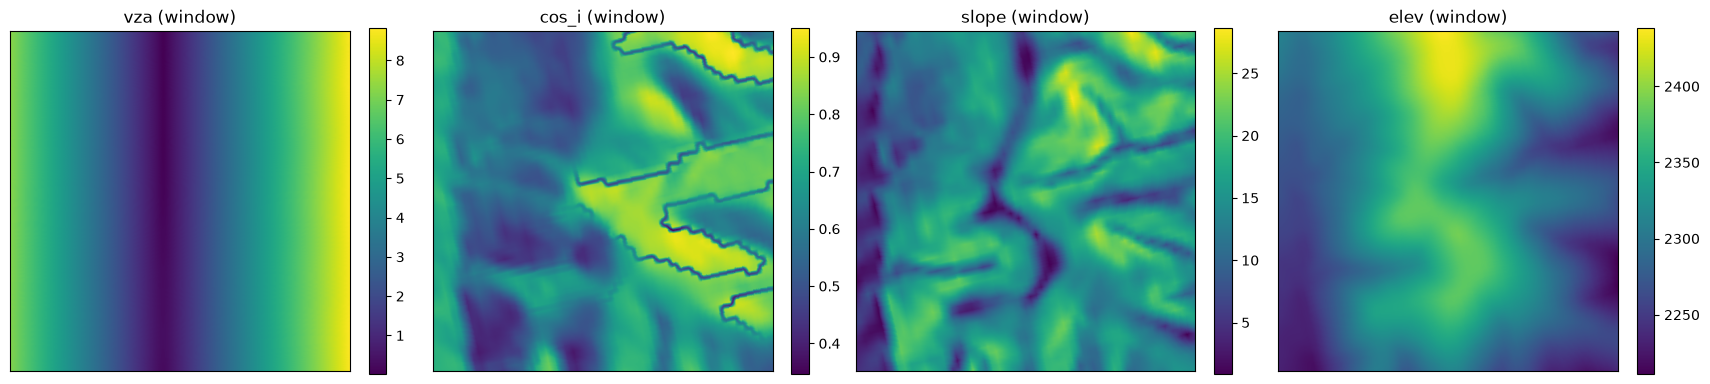

In [7]:
print("angles and terrain on the first line:\n")
for v in ("sza", "saa", "vza", "vaa", "raa", "slope", "aspect", "cos_i", "elev"):
    if v in ds0:
        a = np.asarray(ds0[v].values, dtype="float64")
        print(f"  {v:6s} {np.nanmin(a):8.2f} .. {np.nanmax(a):8.2f}   spread {np.nanmax(a)-np.nanmin(a):7.2f}")
print(f"\nview zenith spans {np.nanmax(ds0.vza.values)-np.nanmin(ds0.vza.values):.1f} degrees across this line.")
print("A satellite in this package spans 0.3 to 2. That is why the BRDF model below is fitted,")
print("not borrowed from MODIS.")

layers = [v for v in ("vza", "cos_i", "slope", "elev") if v in ds0]
fig, ax = plt.subplots(1, len(layers), figsize=(4.3 * len(layers), 4.2))
sub = ds0.isel(y=slice(*WINDOW["y"]), x=slice(*WINDOW["x"]))
for a, v in zip(np.atleast_1d(ax), layers):
    im = a.imshow(sub[v].values, cmap="viridis"); a.set_title(f"{v} (window)")
    a.set_xticks([]); a.set_yticks([]); plt.colorbar(im, ax=a, fraction=0.046)
plt.tight_layout(); plt.show()

## Step 2 — writing, in either format

### `hp.to_geotiff(ds, path, var=None, compress="deflate", overviews=None, overview_resampling="average")`

| Parameter | Default | What it does |
|---|---|---|
| `path` | — | a `.tif`, or a directory, in which case the file is named after the granule |
| `var` | the cube | which variable to write |
| `compress` | `"deflate"` | lossless, roughly halves the file |
| `overviews` | `None` | `True` builds internal pyramids so a GIS can draw without reading at full resolution |
| `overview_resampling` | `"average"` | right for reflectance; use `"nearest"` or `"mode"` for a flag layer |

### `hp.to_envi(ds, path, var=None, interleave="bil")`

| Parameter | Default | What it does |
|---|---|---|
| `path` | — | an `.img`, or a directory. The header lands beside it as `<stem>.hdr` |
| `interleave` | `"bil"` | `"bil"`, `"bip"` or `"bsq"`. BIL is the hyperspectral norm |

**Why ENVI.** A GeoTIFF labels a band with free text; an ENVI header states `wavelength`,
`fwhm` and `bbl` as numbers, so band centres, widths and the **bad-band list** survive.
A GeoTIFF cannot carry a bad-band list at all. On a 284 bands instrument
with real dead bands, that matters.

### `hp.to_raster(ds, path, format="GTiff", **kwargs)`

Picks between the two; `EXPORT_FORMAT` drives the whole notebook.

### `hp.to_geotiff_2d(ds, path, var, overviews=None, overview_resampling="average", tags=None, format="GTiff")`

For a single 2-D layer: an elevation model, a retrieved aerosol map, a flag band.

| Parameter | Default | What it does |
|---|---|---|
| `var` | — | **required**, the layer to write |
| `tags` | `None` | a dict of metadata written into the file, which is how the flag layer in step 5 carries its own bit meanings |
| `overview_resampling` | `"average"` | use `"nearest"` for a flag layer, where averaging would invent values |
| `format` | `"GTiff"` | ENVI ignores `overviews` with a warning, having no internal pyramids |

### `hp.export_geometry(ds, path, layers=None, ...)` and `hp.bands_to_csv(ds, path)`

The angle and terrain layers a correction consumes, one file each, and the band table as
CSV. Worth writing beside any product, because **the product carries no angles** and
step 7 needs them.

In [8]:
demo = ds0.isel(y=slice(WINDOW["y"][0], WINDOW["y"][0] + 60),
                x=slice(WINDOW["x"][0], WINDOW["x"][0] + 60))
demo_w = for_export(demo)
t0 = time.time()
tif = hp.to_geotiff(demo_w, OUT / "01_read" / "demo.tif", overviews=True)
img = hp.to_envi(demo_w, OUT / "01_read" / "demo.img", interleave="bil")
print(f"GeoTIFF {tif.stat().st_size/1e6:6.2f} MB   ENVI {img.stat().st_size/1e6:6.2f} MB"
      f"   ({time.time()-t0:.1f} s)")
print("\nwhat the ENVI header carries that a GeoTIFF cannot:")
for line in img.with_suffix(".hdr").read_text().splitlines():
    if line.split("=")[0].strip() in ("wavelength units", "interleave", "data ignore value", "sensor"):
        print("   ", line)
    for kk in ("wavelength =", "fwhm =", "bbl ="):
        if line.startswith(kk):
            print(f"    {kk:14s} {line.split('=',1)[1].strip()[:56]} ...")

hp.bands_to_csv(demo_w, OUT / "01_read" / "demo_bands.csv")
written = hp.export_geometry(demo_w, OUT / "01_read" / "geometry",
                             layers=("sza", "vza", "raa", "cos_i", "slope"))
print("\ngeometry layers written:", [p.name for p in written])

/home/fujiang/miniconda3/envs/hsi/lib/python3.12/site-packages/rioxarray/rioxarray.py:431: UserWarning: Transform that is non-rectilinear or with rotation found. Unable to recalculate.
  warnings.warn(


/home/fujiang/miniconda3/envs/hsi/lib/python3.12/site-packages/rioxarray/rioxarray.py:431: UserWarning: Transform that is non-rectilinear or with rotation found. Unable to recalculate.
  warnings.warn(


GeoTIFF   3.13 MB   ENVI   4.09 MB   (0.6 s)

what the ENVI header carries that a GeoTIFF cannot:
    interleave = bil
    data ignore value = nan
    bbl =          {1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1 ...
    fwhm =         {8.30171, 8.30249, 8.30332, 8.30422, 8.30514, 8.30612, 8 ...
    sensor = AVIRIS-3
    wavelength =   {389.7549244, 397.1545554, 404.5571739, 411.9627694, 419 ...
    wavelength units = Nanometers



geometry layers written: ['AV320231005t181518_L2A_sza.tif', 'AV320231005t181518_L2A_vza.tif', 'AV320231005t181518_L2A_raa.tif', 'AV320231005t181518_L2A_cos_i.tif', 'AV320231005t181518_L2A_slope.tif']


## Step 3 — from L1B radiance: atmospheric correction

### `hp.atmos.process(source, out_dir, ...)`

One call from radiance to a finished product: the reflectance cube, the retrieved aerosol
and water-vapour layers, the quality flags, a band CSV and a provenance JSON.

| Parameter | Default | What it does |
|---|---|---|
| `source` | — | the L1B file or folder, or an already-opened dataset |
| `out_dir` | — | where the products go |
| `work_dir` | `out_dir/isofit_work/<stem>` | where ISOFIT works. **A finished run here is reused**, which is how you resume; delete the folder to force a redo |
| `stages` | `("ac",)` | airborne keeps this at `("ac",)`: the geometric corrections need the group fits from step 4, so they are applied there, not chained here |
| `engine` | `"sRTMnet"` | the radiative-transfer engine; `"6S"` and `"LibRadTran"` also work |
| `workers` | `24` | cores for the retrieval |
| `window` | `None` | **set here.** A whole AVIRIS-3 flightline is far too large to retrieve for a tutorial |
| `layers` | `("aot550", "h2o")` | which retrieved 2-D layers to write beside the cube |
| `uncertainty` | `False` | also write the posterior uncertainty cube |
| `quality` | `True` | write the consolidated flag layer |
| `format` | `"GTiff"` | or `"ENVI"` |
| `overwrite` | `False` | redo the retrieval even if the work directory holds one |

Anything else goes to the retrieval: `atmosphere`, `surface`, `segmentation_size`,
`num_neighbors`, `aot_prior_sigma`.

**This is the slow step**, so the cell before it checks the ISOFIT assets and fails in
seconds rather than at minute forty if something is missing.

In [9]:
if RUN_AC:
    from hyperproc.atmos import check
    report = check(engines=("sRTMnet",))
    print("\nISOFIT assets ready:", report["ok"])
    if not report["ok"]:
        print("run `hyperproc-atmos-setup` first; the lines above say what is missing")

2026-09-25 14:13:44,039	INFO util.py:155 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


hyperproc.atmos check  (python 3.12.11, isofit 4.1.5)
  ini      /home/fujiang/.isofit/isofit.ini
  gfortran /usr/bin/gfortran
  make     /usr/bin/make
  data       ok       /data/fujiang/isofit_assets/data
  sixs       ok       /data/fujiang/isofit_assets/sixs  exe /data/fujiang/isofit_assets/sixs/sixsV2.1
  srtmnet    ok       /data/fujiang/isofit_assets/srtmnet
  surface    ok       /data/fujiang/isofit_assets/surface
  everything needed is in place

ISOFIT assets ready: True


In [10]:
if RUN_AC:
    from hyperproc.atmos import process
    t0 = time.time()
    ac = process(l1_path, OUT / "02_ac", work_dir=WORK_DIR, stages=("ac",),
                 workers=WORKERS, window=WINDOW, format=EXPORT_FORMAT,
                 layers=("aot550", "h2o"), overviews=True, verbose=True)
    print(f"\n{(time.time()-t0)/60:.1f} min -> {Path(ac['reflectance']).name}")
    print("layers :", {k: Path(v).name for k, v in ac["layers"].items()})
else:
    ac = None; print("RUN_AC is False; skipped")

process: AV320231005t181518_L1B  stages ('ac',)  engine sRTMnet  work /data/fujiang/Hyperspectral_data_processing/tests/output/AVIRIS3/02_ac/isofit
prepare_inputs: AVIRIS-3 -> apply_oe sensor av3, fid AV320231005t181518; 500 x 500 x 284


  radiance file already present with the right size; kept


ISOFIT inputs for AV320231005t181518  (sensor code av3, fid AV320231005t181518)
  500 lines x 500 samples x 284 bands, radiance x1 -> uW/cm2/nm/sr
  rdn /data/fujiang/Hyperspectral_data_processing/tests/output/AVIRIS3/02_ac/isofit/input/AV320231005t181518_rdn
  loc /data/fujiang/Hyperspectral_data_processing/tests/output/AVIRIS3/02_ac/isofit/input/AV320231005t181518_loc
  obs /data/fujiang/Hyperspectral_data_processing/tests/output/AVIRIS3/02_ac/isofit/input/AV320231005t181518_obs
  valid pixels 100.0%; lat 38.539 lon -111.897 elev 2211..2438 m
  sza 45.6..45.6  vza 0.0..8.8  raa 0..121 deg  utc 18.289 h
reflectance product already present: /data/fujiang/Hyperspectral_data_processing/tests/output/AVIRIS3/02_ac/isofit/output/AV320231005t181518_rfl (overwrite=True to redo)
writing AV320231005t181518_L1B_ac_win3000-3500_400-900.tif  ({'wavelength': 284, 'x': 500, 'y': 500}) ...


/home/fujiang/miniconda3/envs/hsi/lib/python3.12/site-packages/rioxarray/_io.py:1148: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  warnings.warn(str(rio_warning.message), type(rio_warning.message))  # type: ignore
/home/fujiang/miniconda3/envs/hsi/lib/python3.12/site-packages/rioxarray/_io.py:1148: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  warnings.warn(str(rio_warning.message), type(rio_warning.message))  # type: ignore
/home/fujiang/miniconda3/envs/hsi/lib/python3.12/site-packages/rioxarray/_io.py:1148: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  warnings.warn(str(rio_warning.message), type(rio_warning.message))  # type: ignore
/home/fujiang/miniconda3/envs/hsi/lib/python3.12/site-packages/rioxarray/_io.py:1148: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identit

quality: clear 100.0%
done in 0.7 min -> /data/fujiang/Hyperspectral_data_processing/tests/output/AVIRIS3/02_ac/AV320231005t181518_L1B_ac_win3000-3500_400-900.tif

0.7 min -> AV320231005t181518_L1B_ac_win3000-3500_400-900.tif
layers : {'aot550': 'AV320231005t181518_L1B_ac_win3000-3500_400-900_aot550.tif', 'h2o': 'AV320231005t181518_L1B_ac_win3000-3500_400-900_h2o.tif'}


/home/fujiang/miniconda3/envs/hsi/lib/python3.12/site-packages/rioxarray/rioxarray.py:431: UserWarning: Transform that is non-rectilinear or with rotation found. Unable to recalculate.
  warnings.warn(


our retrieval against the NASA JPL L2A at 865 nm, 250,000 pixels:
   median difference +0.0022   RMSE 0.0023   r 0.9998


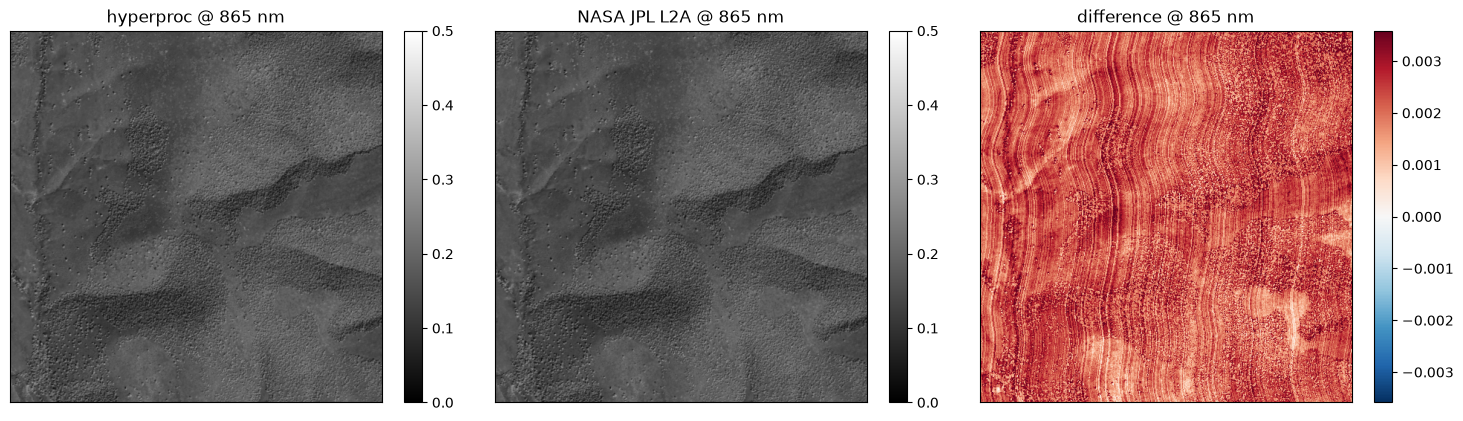

In [11]:
if RUN_AC:
    # our retrieval against the provider's own reflectance, on the same ground
    with rasterio.open(ac["reflectance"]) as src:
        wl_ours = np.array([float(d.split()[0]) for d in src.descriptions])
        b = int(np.argmin(np.abs(wl_ours - DIAG_NM)))
        ours = src.read(b + 1)
    k = int(np.argmin(np.abs(ds0.wavelength.values - DIAG_NM)))
    theirs = window_of(ds0)[VAR].isel(wavelength=k).values   # by index: see the note above

    ok = np.isfinite(ours) & np.isfinite(theirs) & (ours > 0) & (theirs > 0)
    print(f"our retrieval against the NASA JPL L2A at {DIAG_NM:.0f} nm, {ok.sum():,} pixels:")
    if ok.sum() > 100:
        print(f"   median difference {np.median(ours[ok]-theirs[ok]):+.4f}"
              f"   RMSE {np.sqrt(np.mean((ours[ok]-theirs[ok])**2)):.4f}"
              f"   r {np.corrcoef(ours[ok], theirs[ok])[0,1]:.4f}")
    lim = float(np.nanpercentile(np.abs(ours - theirs), 98)) or 0.02
    fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
    for a, img, t, kw in ((ax[0], ours, "hyperproc", dict(cmap="gray", vmin=0, vmax=0.5)),
                          (ax[1], theirs, "NASA JPL L2A", dict(cmap="gray", vmin=0, vmax=0.5)),
                          (ax[2], ours-theirs, "difference", dict(cmap="RdBu_r", vmin=-lim, vmax=lim))):
        im = a.imshow(img, **kw); a.set_title(f"{t} @ {DIAG_NM:.0f} nm"); a.set_xticks([]); a.set_yticks([])
        plt.colorbar(im, ax=a, fraction=0.046)
    plt.tight_layout(); plt.show()

## Step 4 — the group workflow: topographic and BRDF correction

This is what airborne processing actually is. Four moves:

1. **sample** each flightline, because fitting on every pixel of 5 lines is
   pointless and slow;
2. **fit the topographic correction per line**, and read its verdict;
3. **fit the BRDF model on the pooled group**, because one line does not span enough
   geometry;
4. **apply** and write the window.

### 4.1 Sampling

### `hc.sample_image(ds, fraction=0.1, max_pixels=None, seed=0, edge_px=30, min_blocks=4, strategy="pixels", ...)`

| Parameter | Default | What it does |
|---|---|---|
| `fraction` | `0.1` | fraction of the image to draw |
| `max_pixels` | `None` | hard cap. **250,000 here** — enough to fit, small enough to hold 5 lines in memory at once |
| `seed` | `0` | the draw is reproducible |
| `edge_px` | `30` | pixels to ignore at the swath edges, where geometry and radiometry are least reliable |
| `min_blocks` | `4` | the image is drawn in blocks so the sample is spread over it, not clumped |
| `strategy` | `"pixels"` | **the parameter that decides how long this notebook takes.** See below |
| `topo_calc`, `brdf_calc` | published dicts | the masks that decide which pixels are eligible - NDVI range, minimum slope, minimum `cos_i`, a cloud screen |

#### `SAMPLE_REGION`: read a slice of the line, not all of it

Reading every flightline in full is the reference procedure and it is slow — about six
minutes per line on this data, and it dominates everything else in this notebook. It is
also more than the fits need. Two measurements decide how much can safely be cut.

**First: never cut columns.** View zenith varies *across* track, so the swath width is the
angular range the BRDF model is fitted on. Sampling one AVIRIS-3 line:

| region | pixels | view-zenith span | topo bands usable | `angular_diversity` |
|---|---|---|---|---|
| 500 x 500 (the export window) | 0.25 M | 8.8 deg | 66 | **insufficient** — span 5.1 deg, condition 5560 |
| 500 x 1342 (full width) | 0.67 M | 21.2 deg | 235 | **ok** — span 16.0 deg, condition 746 |

Cutting the swath to the export window throws away most of the angular range and the fit
is refused, correctly: five degrees cannot separate the kernels.

**Second: cut rows, but not to the window.** Rows cost read time and buy terrain variety,
which is what the *topographic* fit needs — it is judged by whether independent blocks of
the image agree, and a short band has too few blocks to tell.

| rows read | NEON verdict | blocks | effect | time per line |
|---|---|---|---|---|
| 500 | **skip** — no effect found | 8 | -0.017 | 21 s |
| **2000** | **inconclusive** | 28 | +0.059 | 64 s |
| 4000 | inconclusive | 52 | +0.140 | 124 s |
| 10749 (full) | inconclusive | 125 | +0.072 | 362 s |

At 500 rows the topographic fit reports `skip` on NEON and AVIRIS-5 — not because there is
no terrain effect, but because the band is too short to demonstrate one. **2000 rows
recovers the same verdict as the whole line on every sensor tested, at a fifth of the
cost**, and that is the default.

So: full swath width, a 2000-row band centred on the export window. The fit then describes
that band rather than the whole flightline, which is the honest reading of its verdict, and
the band contains the window the products cover.

#### `strategy`, and why sampling is the slow part

| Value | What it does | Cost |
|---|---|---|
| `"pixels"` (default) | the **reference procedure**: reads the whole flightline once to build every mask on every pixel, draws a random `fraction` of those that pass, and accumulates the topographic regression sums over **all** eligible pixels while reading — the exact all-pixel NNLS result without holding the cube in memory | **two passes over the cube** |
| `"chunks"` | reads `fraction` of the reader's chunks, spread evenly over the grid, and keeps up to `max_pixels` random pixels from them. Cloud statistics and the NDVI population come only from the chunks read | about **a tenth of one pass** |

This notebook keeps `"pixels"`, the reference procedure, applied to whatever
`SAMPLE_REGION` selects. With the default `"rows"` that is fast enough that the cheaper
`"chunks"` is not needed; set it if you shrink nothing else and still want a quick look,
remembering that its verdicts should not be quoted.

A `Sample` carries the reflectance, angles and terrain of the drawn pixels, plus the masks.
`s.summary()` prints what it got, including whether the whole image was read.

In [12]:
if RUN_TOPO or RUN_BRDF:
    t0 = time.time()
    samples = []
    for ds in dss:
        s = hc.sample_image(sample_region(ds), fraction=FRACTION, max_pixels=MAX_PIXELS,
                            strategy=SAMPLE_STRATEGY)
        samples.append(s)
        print("  ", s.summary())
    print(f"\nsampled {len(samples)} flightlines in {time.time()-t0:.0f} s")

   AV320231005t181518_L2A: whole image read (2,574,197 valid px); random 10% kept for the BRDF fit = 250,000 px; topo C from all 1,758,287 calc-mask px; vza 1.1-19.2 deg, sza 45.6 deg, read in 33 s


   AV320231005t182159_L2A: whole image read (2,508,323 valid px); random 10% kept for the BRDF fit = 250,000 px; topo C from all 2,450,567 calc-mask px; vza 1.1-19.0 deg, sza 45.2 deg, read in 129 s


   AV320231005t183127_L2A: whole image read (2,617,145 valid px); random 10% kept for the BRDF fit = 250,000 px; topo C from all 2,226,242 calc-mask px; vza 1.0-19.2 deg, sza 44.7 deg, read in 80 s


   AV320231005t184142_L2A: whole image read (2,249,839 valid px); random 10% kept for the BRDF fit = 224,984 px; topo C from all 1,598,316 calc-mask px; vza 1.0-19.2 deg, sza 44.2 deg, read in 88 s


   AV320231005t185153_L2A: whole image read (2,552,809 valid px); random 10% kept for the BRDF fit = 250,000 px; topo C from all 1,808,167 calc-mask px; vza 1.1-19.1 deg, sza 43.9 deg, read in 89 s

sampled 5 flightlines in 418 s


### 4.2 The topographic correction, and its verdict

A slope tilted towards the sun receives more irradiance and looks brighter. SCS+C removes
that by regressing reflectance on `cos_i`, the cosine of the incidence angle between the
sun and the surface normal, band by band.

### `hc.fit_topo(sample, method="scs+c", fit="nnls", calc=..., apply_spec=..., diagnostic_bands=40, min_samples=100, block_agreement=0.7, block_min_pixels=500, block_split=2, block_t=2.0)`

| Parameter | Default | What it does |
|---|---|---|
| `method` | `"scs+c"` | sun-canopy-sensor with the C correction. The C term stops the correction exploding as `cos_i` goes to zero |
| `fit` | `"nnls"` | non-negative least squares. **This default matters**: ordinary least squares can return a negative intercept, which makes C negative and the correction singular. NNLS cannot |
| `calc` | NDVI 0.1-1.0, slope ≥ 5°, `cos_i` ≥ 0.12, a cloud screen | which pixels the regression is *fitted* on |
| `apply_spec` | same bounds without the cloud screen | which pixels the correction is *applied* to |
| `diagnostic_bands` | `40` | bands used for the verdict |
| `min_samples` | `100` | fewer eligible pixels than this and the fit is refused |
| `block_split` | `2` | the image is split into blocks and fitted separately; a correction that is real should agree between them |
| `block_agreement` | `0.7` | the fraction of blocks that must agree before the verdict is `correct` |
| `block_t` | `2.0` | the t-statistic a block's slope must reach to count as significant |

**Read the verdict.** `correct` means the terrain effect is present and consistent;
`inconclusive` means the fit could not prove it, usually because the line's terrain is too
uniform or its slopes too gentle. This notebook applies the correction anyway with
`force_topo=True` so you can *see* what it does — in production you would let the verdict
decide.

In [13]:
if RUN_TOPO:
    t0 = time.time()
    topos = [hc.fit_topo(s) for s in samples]
    for t in topos:
        t.to_json(OUT / "03_coefficients")
    rows = []
    for t in topos:
        d = t.diagnostic
        rows.append(dict(image=str(t.source["stem"])[:34], verdict=t.verdict,
                         blocks=f"{d.get('n_blocks_significant')}/{d.get('n_blocks')}",
                         agreement=d.get("block_agreement"),
                         n_fit=t.n_samples, bands_ok=t.n_ok,
                         median_C=float(np.nanmedian(t.c)) if np.isfinite(t.c).any() else np.nan,
                         effect_before=d["median_effect_before"], effect_after=d["median_effect_after"]))
    display(pd.DataFrame(rows))
    print(f"fitted {len(topos)} lines in {time.time()-t0:.0f} s")
    print("\nverdicts:", {t.verdict for t in topos})
    print("'correct' = the terrain effect is present and consistent between blocks.")
    print("'inconclusive' = the fit could not prove it; this notebook forces it anyway to show the effect.")
else:
    topos = None

,image,verdict,blocks,agreement,n_fit,bands_ok,median_C,effect_before,effect_after
0,AV320231005t181518_L2A,skip,116/153,0.5690,1758287,157,18.6856,0.0050,0.0015
1,AV320231005t182159_L2A,inconclusive,152/196,0.5789,2450567,0,NaN,-0.1060,NaN
2,AV320231005t183127_L2A,refuse,176/202,0.7386,2226242,0,NaN,-0.3709,NaN
3,AV320231005t184142_L2A,inconclusive,126/159,0.5079,1598316,69,6.9763,-0.0791,0.0144
4,AV320231005t185153_L2A,refuse,122/164,0.8279,1808167,0,NaN,-0.2100,NaN


fitted 5 lines in 52 s

verdicts: {'inconclusive', 'skip', 'refuse'}
'correct' = the terrain effect is present and consistent between blocks.
'inconclusive' = the fit could not prove it; this notebook forces it anyway to show the effect.


band status over 284 bands: {np.str_('bad_band'): 35, np.str_('inverted'): 92, np.str_('ok'): 157}
  'ok' bands get the correction; 'inverted' ones would darken a sunlit slope,
  so the fit refuses them and leaves those bands alone.


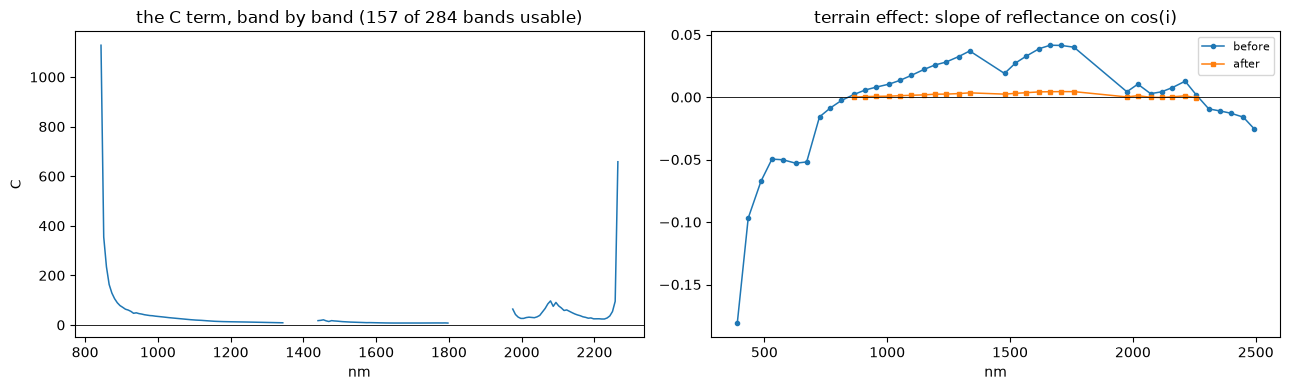

In [14]:
if RUN_TOPO:
    # what the correction is actually doing, band by band, on the first line.
    # The per-band numbers live in diagnostic["bands"], keyed by wavelength string,
    # and only the `diagnostic_bands` sample of them is kept (40 by default).
    t = topos[0]
    bands = t.diagnostic["bands"]
    wl_d = np.array([float(w) for w in bands])
    order = np.argsort(wl_d); wl_d = wl_d[order]
    take = lambda k: np.array([bands[w][k] if bands[w][k] is not None else np.nan
                               for w in bands], dtype="float64")[order]
    eb, ea = take("effect_before"), take("effect_after")

    status = np.array(t.status)
    counts = {v: int((status == v).sum()) for v in sorted(set(status))}
    print(f"band status over {status.size} bands: {counts}")
    print(f"  'ok' bands get the correction; 'inverted' ones would darken a sunlit slope,")
    print(f"  so the fit refuses them and leaves those bands alone.")

    fig, ax = plt.subplots(1, 2, figsize=(13, 4))
    ax[0].plot(np.asarray(t.wavelength), t.c, lw=1.1)
    ax[0].axhline(0, color="k", lw=0.6)
    ax[0].set_xlabel("nm"); ax[0].set_ylabel("C")
    ax[0].set_title(f"the C term, band by band ({t.n_ok} of {status.size} bands usable)")
    ax[1].plot(wl_d, eb, "o-", ms=3, lw=1.1, label="before")
    ax[1].plot(wl_d, ea, "s-", ms=3, lw=1.1, label="after")
    ax[1].axhline(0, color="k", lw=0.6); ax[1].legend(fontsize=8)
    ax[1].set_xlabel("nm"); ax[1].set_title("terrain effect: slope of reflectance on cos(i)")
    plt.tight_layout(); plt.show()

### 4.3 Can this group support a BRDF fit at all?

### `hc.angular_diversity(sza, vza, raa, mask=None, volume="ross_thick", geometric="li_dense_r", b_r=1.0, h_b=2.0, span_min_deg=8.0, cond_max=2000.0)`

Before fitting, ask whether the geometry can support a fit. It builds the same kernel pair
the model uses and reports the condition number of the design matrix.

| Parameter | Default | What it does |
|---|---|---|
| `span_min_deg` | `8.0` | the view-zenith span below which a fit is refused |
| `cond_max` | `2000.0` | the condition number above which the kernels are too collinear to separate |
| `b_r`, `h_b` | `1.0`, `2.0` | Li kernel crown shape and height — **1.0 and 2.0 here** |

This flight spans about 22 degrees, so expect this to pass. On a
satellite it would not, which is the whole reason satellites borrow MODIS parameters.

### `hc.fit_brdf(samples, topo=None, calc=..., apply_spec=..., volume="ross_thick", geometric="li_dense_r", b_r=1.0, h_b=2.0, sza_ref="group", num_bins=18, ndvi_min=0.05, ndvi_max=1.0, perc_min=10, perc_max=95, second_split=True, group_id=None, force=False, force_topo=False)`

| Parameter | Default | What it does |
|---|---|---|
| `samples` | — | the **group's** samples, pooled. One line is not enough geometry |
| `topo` | `None` | the topographic coefficients to remove first. `None` fits on raw samples, which is what the `_brdf` product wants; passing them gives the `_topo_brdf` product a cleaner signal |
| `volume` | `"ross_thick"` | the volume-scattering kernel |
| `geometric` | `"li_dense_r"` | the geometric-optical kernel. Airborne uses the *dense* reciprocal form; the satellite c-factor uses the sparse one |
| `sza_ref` | `"group"` | the solar zenith to normalise to. `"group"` uses the group mean, so lines flown an hour apart land on a common sun |
| `num_bins` | `18` | NDVI bins. The model is fitted per bin, because canopy scattering depends on how much canopy there is |
| `ndvi_min`, `ndvi_max` | `0.05`, `1.0` | the NDVI range that gets a fit |
| `perc_min`, `perc_max` | `10`, `95` | percentile trim inside each bin, which keeps outliers out of the regression |
| `second_split` | `True` | split each bin again and check the two halves agree |
| `force` | `False` | fit even when the diversity check says no |
| `force_topo` | `False` | accept topographic coefficients whose verdict was not `correct` |

Two fits are made below, because the two products need different ones:

* `bc_plain` — fitted on **raw** samples, for `*_brdf.tif`;
* `bc_after` — fitted on **topographically corrected** samples, for `*_topo_brdf.tif`.

In [15]:
if RUN_BRDF:
    pooled = {k: np.concatenate([getattr(s, k)[s.brdf_calc_mask(
                 hc.pipeline.BRDF_CALC, "ross_thick", "li_dense_r", B_R, H_B)]
                 for s in samples]) for k in ("sza", "vza", "raa")}
    div = hc.angular_diversity(pooled["sza"], pooled["vza"], pooled["raa"], b_r=B_R, h_b=H_B)
    for k in ("verdict", "n", "vza_span_deg", "vza_p05_deg", "vza_p95_deg",
              "sza_mean_deg", "condition_number", "reason"):
        if k in div:
            v = div[k]
            print(f"  {k:18s} {round(v, 2) if isinstance(v, float) else v}")

  verdict            ok
  n                  949515
  vza_span_deg       15.52
  vza_p05_deg        2.89
  vza_p95_deg        18.41
  sza_mean_deg       44.77
  condition_number   497.92
  reason             None


In [16]:
if RUN_BRDF:
    t0 = time.time()
    bc_plain = hc.fit_brdf(samples, topo=None, b_r=B_R, h_b=H_B,
                           group_id=OUT.name, force_topo=True)
    bc_after = hc.fit_brdf(samples, topo=topos, b_r=B_R, h_b=H_B,
                           group_id=OUT.name + "_after_topo", force_topo=True)
    bc_plain.to_json(OUT / "03_coefficients"); bc_after.to_json(OUT / "03_coefficients")
    print(bc_plain.summary())
    print(f"\nfitted two BRDF models on {len(samples)} lines in {time.time()-t0:.0f} s")
    print("  bc_plain  -> for *_brdf.tif      (fitted on raw samples)")
    print("  bc_after  -> for *_topo_brdf.tif (fitted after the topographic correction)")
else:
    bc_plain = bc_after = None

brdf fit ross_thick/li_dense_r b/r=1.0 h/b=2.0: 284 bands x 20 bins, sza_ref 44.77 deg, median r2 0.027, group of 5, diversity=ok

fitted two BRDF models on 5 lines in 55 s
  bc_plain  -> for *_brdf.tif      (fitted on raw samples)
  bc_after  -> for *_topo_brdf.tif (fitted after the topographic correction)


### `hc.view_dependence(samples, brdf=None, ...)`

The check that matters: bin the samples by view zenith and report mean reflectance per
bin, before and after. A working BRDF correction flattens the across-track gradient. It is
reported per NDVI class, because the gradient's size depends on how much canopy there is.

In [17]:
if RUN_BRDF:
    vd = hc.view_dependence(samples, brdf=bc_plain)
    rows = []
    for c in vd["classes"]:
        for k, w in enumerate(vd["wavelength"]):
            rows.append(dict(ndvi=f"{c['ndvi'][0]:.1f}-{c['ndvi'][1]:.1f}", n=c["n"], nm=round(w),
                             before=c["before"][k],
                             after=(c.get("after") or [np.nan] * len(vd["wavelength"]))[k]))
    tab = pd.DataFrame(rows).pivot(index=["ndvi", "n"], columns="nm", values=["before", "after"])
    display(tab)
    print("'before' and 'after' are the across-track slope of reflectance on view zenith.")
    print("Closer to zero after the correction is the result you want.")

before                                   after                                
nm                553     657     851     1649    2198    553     657     851     1649    2198
ndvi    n                                                                                     
0.3-0.5 370988  0.1050  0.1040  0.1086  0.0764  0.0769  0.0002  0.0010  0.0013  0.0053  0.0057
0.5-0.7 258866  0.1457  0.0765  0.0816 -0.0612 -0.0433 -0.0043 -0.0091 -0.0007 -0.0044 -0.0049
0.7-0.9 106915  0.2136  0.1405  0.0673 -0.0174 -0.0059  0.0580  0.0777  0.0208  0.0713  0.0767

'before' and 'after' are the across-track slope of reflectance on view zenith.
Closer to zero after the correction is the result you want.


### 4.4 Applying them, and writing the window

### `hc.apply(ds, topo=None, brdf=None, block_bytes=2e8, notes=None, force_topo=False, brdf_ratio_max=5.0)`

| Parameter | Default | What it does |
|---|---|---|
| `topo` | `None` | the line's topographic coefficients. `None` skips the stage |
| `brdf` | `None` | the group's BRDF coefficients. `None` skips the stage |
| `block_bytes` | `2e8` | how much of the cube to hold at once. Lower it if memory is tight |
| `notes` | `None` | a dict recorded in the output's attributes — this notebook records the verdict and whether it was forced |
| `force_topo` | `False` | apply topographic coefficients whose verdict was not `correct`. **Used here** so the effect is visible; leave it `False` in production |
| `brdf_ratio_max` | `5.0` | cap on the BRDF multiplier, so a near-zero modelled reflectance cannot produce a wild ratio |

The result is lazy. Nothing is computed until it is written.

### `hc.export(ds, out_dir, wavelengths=None, window=None, suffix="", compress="deflate", workers=4, overviews=None, overview_resampling="average", format="GTiff")`

| Parameter | Default | What it does |
|---|---|---|
| `window` | `None` | `(row0, row1, col0, col1)`. **Always set for airborne** — a whole flightline is hundreds of GB |
| `wavelengths` | `None` | write only these bands. `None` writes the cube |
| `suffix` | `""` | appended to the stem, which is how the stage products get their names |
| `workers` | `4` | threads for the write |
| `format` | `"GTiff"` | or `"ENVI"` |

Three products come out, and the names say what is in them:
`*_topo`, `*_brdf`, `*_topo_brdf`.

In [18]:
if RUN_TOPO or RUN_BRDF:
    tc0 = topos[0] if topos else None
    note = {"topo_verdict": tc0.verdict, "topo_forced": tc0.verdict != "correct"} if tc0 else None
    stages = {}
    if RUN_TOPO:
        stages["topo"] = hc.apply(ds0, topo=tc0, notes=note, force_topo=True)
    if RUN_BRDF:
        stages["brdf"] = hc.apply(ds0, brdf=bc_plain)
    if RUN_TOPO and RUN_BRDF:
        stages["topo_brdf"] = hc.apply(ds0, topo=tc0, brdf=bc_after, notes=note, force_topo=True)

    win = (WINDOW["y"][0], WINDOW["y"][1], WINDOW["x"][0], WINDOW["x"][1])
    stage_paths = {}
    for st, cor in stages.items():
        t1 = time.time()
        stage_paths[st] = hc.export(cor, OUT / "04_corrected", window=win, suffix=f"_{st}",
                                    overviews=(EXPORT_FORMAT == "GTiff"), format=EXPORT_FORMAT)
        print(f"  {st:10s} -> {stage_paths[st].name}  "
              f"({stage_paths[st].stat().st_size/1e6:.0f} MB, {time.time()-t1:.0f} s)")

/home/fujiang/miniconda3/envs/hsi/lib/python3.12/site-packages/rioxarray/rioxarray.py:431: UserWarning: Transform that is non-rectilinear or with rotation found. Unable to recalculate.
  warnings.warn(


  topo       -> AV320231005t181518_L2A_topo_topo.tif  (214 MB, 5 s)


/home/fujiang/miniconda3/envs/hsi/lib/python3.12/site-packages/rioxarray/rioxarray.py:431: UserWarning: Transform that is non-rectilinear or with rotation found. Unable to recalculate.
  warnings.warn(


  brdf       -> AV320231005t181518_L2A_brdf_brdf.tif  (214 MB, 8 s)


/home/fujiang/miniconda3/envs/hsi/lib/python3.12/site-packages/rioxarray/rioxarray.py:431: UserWarning: Transform that is non-rectilinear or with rotation found. Unable to recalculate.
  warnings.warn(


  topo_brdf  -> AV320231005t181518_L2A_topo_brdf_topo_brdf.tif  (214 MB, 10 s)


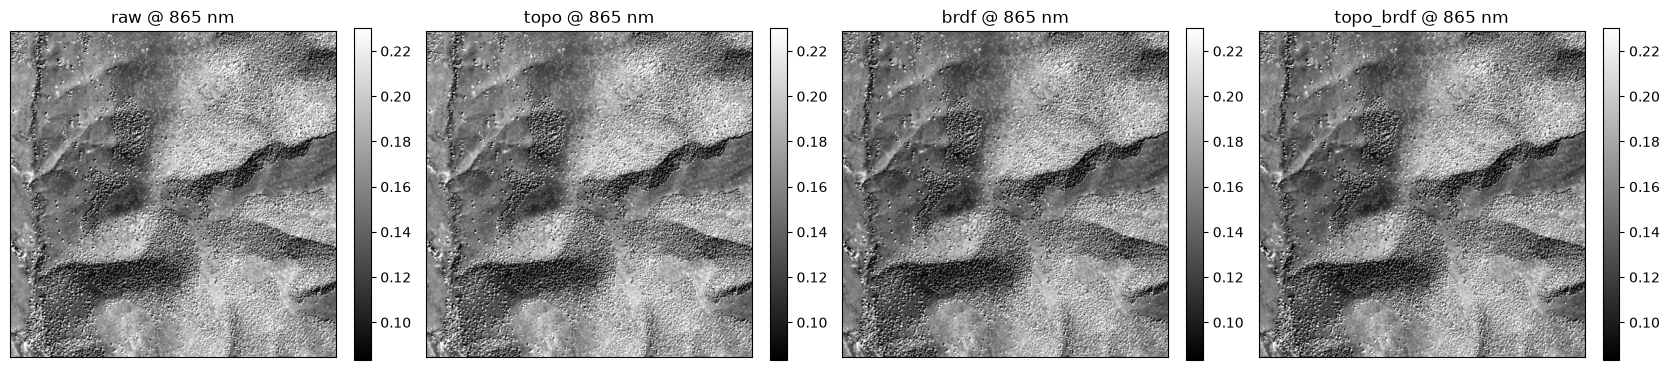

  topo       median change  +0.02 %   p5  -0.13 %   p95  +0.13 %
  brdf       median change  -3.45 %   p5  -6.25 %   p95  -0.27 %
  topo_brdf  median change  -3.43 %   p5  -6.19 %   p95  -0.32 %


In [19]:
if RUN_TOPO or RUN_BRDF:
    # raw and each stage, at one wavelength, on exactly the same ground
    k = int(np.argmin(np.abs(ds0.wavelength.values - DIAG_NM)))
    raw = ds0[VAR].isel(wavelength=k, y=slice(*WINDOW["y"]), x=slice(*WINDOW["x"])).values
    panels = [("raw", raw)]
    for st, p in stage_paths.items():
        with rasterio.open(p) as src:
            wl_p = np.array([float(d.split()[0]) for d in src.descriptions])
            panels.append((st, src.read(int(np.argmin(np.abs(wl_p - DIAG_NM))) + 1)))
    vmin, vmax = np.nanpercentile(raw[np.isfinite(raw)], [2, 98]) if np.isfinite(raw).any() else (0, 0.5)
    fig, ax = plt.subplots(1, len(panels), figsize=(4.2 * len(panels), 4.4))
    for a, (t, img) in zip(np.atleast_1d(ax), panels):
        im = a.imshow(img, cmap="gray", vmin=vmin, vmax=vmax)
        a.set_title(f"{t} @ {DIAG_NM:.0f} nm"); a.set_xticks([]); a.set_yticks([])
        plt.colorbar(im, ax=a, fraction=0.046)
    plt.tight_layout(); plt.show()

    for t, img in panels[1:]:
        d = img - raw
        ok = np.isfinite(d) & np.isfinite(raw) & (raw > 0.01)
        if ok.sum():
            print(f"  {t:10s} median change {np.median(d[ok]/raw[ok])*100:+6.2f} %   "
                  f"p5 {np.percentile(d[ok]/raw[ok], 5)*100:+6.2f} %   "
                  f"p95 {np.percentile(d[ok]/raw[ok], 95)*100:+6.2f} %")

### 4.5 The seam check — the test only airborne can run

Adjacent flightlines overlap, and in the overlap the **same ground** was seen from two
different view angles, often on different headings. That is an independent check no
satellite scene can offer: if the BRDF correction is doing its job, the two lines should
agree better after it than before.

### `hc.find_overlapping_pair(datasets, exclude_same=None)`

Returns `(i, j, area)` for the pair with the largest footprint overlap, or `None`.
`exclude_same` takes a function mapping a dataset to a group key, so chunks of the *same*
flightline are not compared with each other — which would prove nothing.

### `hc.seam_check(ds_a, ds_b, cor_a, cor_b, out_dir, wavelengths=(450, 550, 650, 850, 1650, 2200), max_rows=1200, tag="seam", overviews=None)`

Crops both lines to their overlap, before and after correction, writes the four crops and
reports agreement per wavelength: median absolute relative difference, the p90, the ratio
and the correlation.

**Lower `median_abs_rel_diff` after correction is the result you want.**

In [20]:
if (RUN_TOPO or RUN_BRDF) and len(dss) > 1:
    t0 = time.time()
    line_of = (lambda d: str(d.attrs.get("stem", ""))[:18]) if len(dss) > N_LINES else None
    pair = hc.find_overlapping_pair(dss, exclude_same=line_of)
    if pair is None:
        print("no two images in this group overlap; skipping the seam check")
        seam = None
    else:
        i, j, area = pair
        print(f"largest overlap: {dss[i].attrs.get('stem')} <-> {dss[j].attrs.get('stem')}"
              f"  ({area/1e6:.1f} km2, found in {time.time()-t0:.0f} s)")
        fin = lambda k: hc.apply(dss[k], topo=topos[k] if RUN_TOPO else None,
                                 brdf=bc_after if RUN_BRDF else None, force_topo=True)
        seam = hc.seam_check(dss[i], dss[j], fin(i), fin(j), OUT / "05_seam",
                             tag=f"{OUT.name}_seam", overviews=False)

largest overlap: AV320231005t184142_L2A <-> AV320231005t185153_L2A  (89.9 km2, found in 0 s)


/data/fujiang/Hyperspectral_data_processing/hyperproc/correct/pipeline.py:777: UserWarning: AV320231005t185153_L2A: topo coefficients have no C for any band; the topo stage changes nothing
  warnings.warn(f"{ds.attrs.get('stem')}: topo coefficients have no C for any band; the topo stage changes nothing")


/home/fujiang/miniconda3/envs/hsi/lib/python3.12/site-packages/rioxarray/rioxarray.py:431: UserWarning: Transform that is non-rectilinear or with rotation found. Unable to recalculate.
  warnings.warn(


/home/fujiang/miniconda3/envs/hsi/lib/python3.12/site-packages/rioxarray/rioxarray.py:431: UserWarning: Transform that is non-rectilinear or with rotation found. Unable to recalculate.
  warnings.warn(


/home/fujiang/miniconda3/envs/hsi/lib/python3.12/site-packages/rioxarray/rioxarray.py:431: UserWarning: Transform that is non-rectilinear or with rotation found. Unable to recalculate.
  warnings.warn(


/home/fujiang/miniconda3/envs/hsi/lib/python3.12/site-packages/rioxarray/rioxarray.py:431: UserWarning: Transform that is non-rectilinear or with rotation found. Unable to recalculate.
  warnings.warn(


In [21]:
if (RUN_TOPO or RUN_BRDF) and len(dss) > 1 and seam:
    rows = []
    for label in ("raw", "corrected"):
        ag = seam[label]["agreement"]
        if ag.get("n", 0) < 100:
            continue
        for k, w in enumerate(ag["wavelength"]):
            rows.append(dict(nm=round(w), stage=label, n=ag["n"],
                             median_abs_rel_diff=ag["median_abs_rel_diff"][k],
                             p90_abs_rel_diff=ag["p90_abs_rel_diff"][k],
                             ratio_a_over_b=ag["median_ratio"][k], r=ag["correlation"][k]))
    if rows:
        tab = pd.DataFrame(rows).pivot(index="nm", columns="stage",
                                       values=["median_abs_rel_diff", "p90_abs_rel_diff", "r"])
        display(tab)
        b = tab["median_abs_rel_diff"]
        if "raw" in b and "corrected" in b:
            imp = (b["raw"] - b["corrected"]) / b["raw"] * 100
            print("improvement in cross-line agreement, per wavelength (%):")
            print("   " + "  ".join(f"{int(w)}nm {v:+.1f}" for w, v in imp.items()))
    else:
        print("too few overlapping pixels to report agreement")

median_abs_rel_diff         p90_abs_rel_diff                 r        
stage           corrected     raw        corrected     raw corrected     raw
nm                                                                          
449                0.2980  0.2946           1.0552  1.1542    0.6967  0.7183
553                0.2212  0.2346           0.7812  0.9209    0.6942  0.7067
650                0.2324  0.2468           0.8960  1.0069    0.7336  0.7535
851                0.1743  0.1843           0.6117  0.6808    0.5387  0.5432
1649               0.2252  0.2040           0.9036  0.8123    0.7492  0.8016
2198               0.2527  0.2356           1.0413  0.9575    0.7787  0.8243

improvement in cross-line agreement, per wavelength (%):
   449nm -1.1  553nm +5.7  650nm +5.8  851nm +5.5  1649nm -10.4  2198nm -7.2


## Step 5 — the quality layer

Every provider names its masks differently. One layer with documented bits makes masking
the same call whatever the instrument — and on airborne data two of the derived flags earn
their keep that the satellites could not use: `terrain_shadow` and `steep_terrain`, both of
which need the per-pixel terrain this sensor carries.

### `hp.quality_flags(ds, var=None, derive=("fill", "terrain_shadow"), negative_fraction=0.1, slope_max=45.0, zhai=False, sources=True, verbose=False)`

| Parameter | Default | What it does |
|---|---|---|
| `derive` | `("fill", "terrain_shadow")` | flags to compute rather than read. `"terrain_shadow"` needs `cos_i`, `"steep_terrain"` needs `slope` — **this sensor has both**, with slopes to 40 degrees |
| `negative_fraction` | `0.1` | fraction of usable bands below zero before `negative_reflectance` is set |
| `slope_max` | `45.0` | degrees above which `steep_terrain` is set |
| `zhai` | `False` | also run a spectral cloud index. Off by default when the provider ships a mask |
| `sources` | `True` | read the provider's own layers as well |

### `hp.quality_apply(ds, quality=None, drop=("fill","cloud","cloud_shadow","cirrus"), var=None, keep=True, derive=("fill",))`

Sets the cube to NaN wherever a dropped flag is set.

### `hp.quality_decode(quality, *names)` and `hp.quality_table(quality)`

A boolean for any combination of flags, and the bit table with the share of pixels carrying
each.

In [22]:
win_ds = ds0.isel(y=slice(*WINDOW["y"]), x=slice(*WINDOW["x"]))
q = hp.quality_flags(win_ds, derive=("fill", "terrain_shadow", "steep_terrain"), slope_max=45.0)
print(hp.quality_table(q))

bit  flag                  share    meaning
---  --------------------  -------  ----------------------------------------------
  0  fill                    0.00 %  no observation (off-swath, nodata, navigation failure)
  1  saturated               0.00 %  a band is at the detector rail
  2  cloud                   0.00 %  opaque cloud
  3  cloud_shadow            0.00 %  shadow cast by cloud
  4  cirrus                  0.00 %  thin or high cloud
  5  snow_ice                0.00 %  snow or ice
  6  water                   0.00 %  inland or ocean water
  7  haze                    0.00 %  aerosol haze flagged by the provider
  8  sun_glint               0.00 %  specular reflection geometry
  9  terrain_shadow          0.00 %  not illuminated by the direct beam (cos i <= 0)
 10  steep_terrain           0.00 %  slope beyond what a topographic correction holds
 11  ac_failed               0.00 %  atmospheric correction did not converge
 12  brdf_filled             0.00 %  BRDF c-factor no

after masking cloud, shadow, cirrus and fill: 100.0 % of the window still carries data


/home/fujiang/miniconda3/envs/hsi/lib/python3.12/site-packages/rioxarray/rioxarray.py:431: UserWarning: Transform that is non-rectilinear or with rotation found. Unable to recalculate.
  warnings.warn(


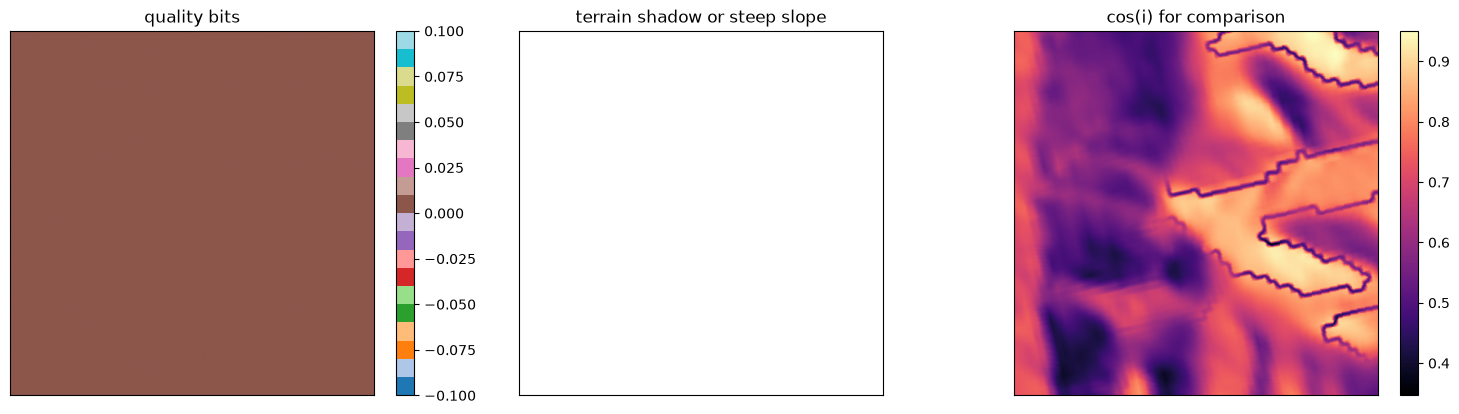

In [23]:
clear = hp.quality_apply(win_ds, q, drop=("fill", "cloud", "cloud_shadow", "cirrus"))
kept = np.isfinite(clear[VAR].isel(wavelength=win_ds.sizes["wavelength"] // 2).values).mean()
print(f"after masking cloud, shadow, cirrus and fill: {kept*100:.1f} % of the window still carries data")

qds = xr.Dataset({"quality": q}, attrs=dict(win_ds.attrs))
hp.to_geotiff_2d(for_export(qds), OUT / "06_quality" / f"quality{EXT}", var="quality",
                 format=EXPORT_FORMAT, overview_resampling="nearest",
                 tags={"flag_bits": q.attrs["flag_bits"], "flag_meanings": q.attrs["flag_meanings"]})

fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
im = ax[0].imshow(q.values, cmap="tab20"); ax[0].set_title("quality bits")
plt.colorbar(im, ax=ax[0], fraction=0.046)
ax[1].imshow(hp.quality_decode(q, "terrain_shadow", "steep_terrain").values, cmap="gray_r")
ax[1].set_title("terrain shadow or steep slope")
im = ax[2].imshow(win_ds.cos_i.values, cmap="magma"); ax[2].set_title("cos(i) for comparison")
plt.colorbar(im, ax=ax[2], fraction=0.046)
for a in ax: a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

## Step 6 — post-processing

Everything here takes a corrected cube and either transforms it, a cube in and a cube out,
in `hyperproc.spectral`, or reduces it to a map, in `hyperproc.features`.

### 6.1 Two smoothers, with opposite contracts

### `hp.smooth_spectra(ds, var=None, window=5, order=2, method="savgol", good_only=True)`

| Parameter | Default | What it does |
|---|---|---|
| `window` | `5` | filter length in bands; odd, greater than `order` |
| `order` | `2` | polynomial order of the local fit |
| `method` | `"savgol"` | Savitzky-Golay, which keeps peak shape, or `"moving"` for a running mean |
| `good_only` | `True` | smooth only within runs of usable bands, so the filter never reaches across a water-vapour gap |

Cosmetic: it cannot invent a value and preserves the NaN pattern exactly.

### `hp.spline_gapfill(ds, var=None, df=60, threshold=0.018, despike=True, exclude=..., mask_after=..., min_points=20, keep_fill_flag=True)`

The opposite, on purpose: despike, blank the artefact regions, fit a smoothing spline
through what survives and evaluate it **everywhere**, then blank the deep water absorptions.

| Parameter | Default | What it does |
|---|---|---|
| `df` | `60` | degrees of freedom; higher follows the spectrum more closely |
| `threshold` | `0.018` | how far a spike must rise above its neighbours |
| `exclude` | 13 windows | blanked **before** the fit, so the spline interpolates across them |
| `mask_after` | 3 windows | blanked **after**, so what it discards was interpolated anyway |
| `min_points` | `20` | a spectrum with fewer surviving bands stays NaN |
| `keep_fill_flag` | `True` | attach `spline_filled`, marking which reported bands are interpolation |

Because it invents values, the flag matters. **Fit narrow features on the unsmoothed cube.**

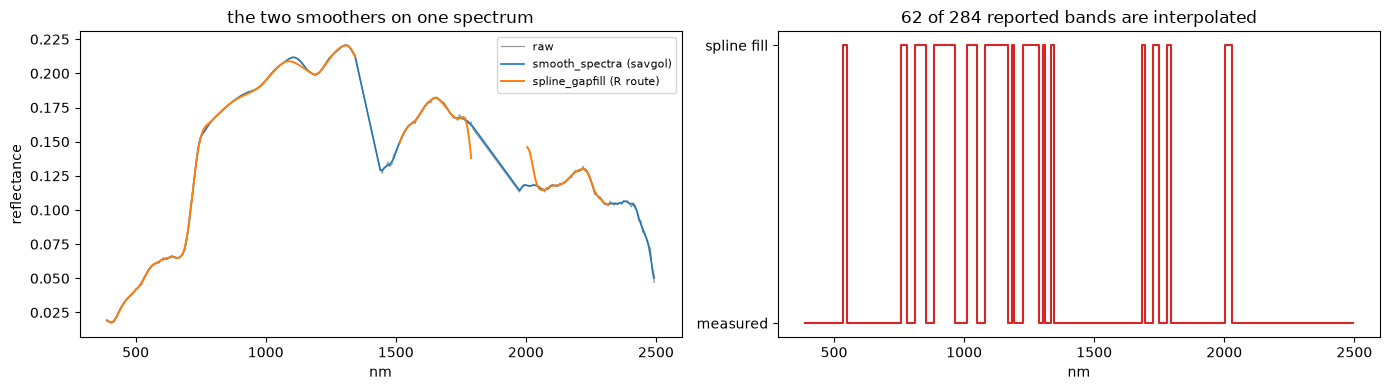

In [24]:
if RUN_POST:
    cy, cx = win_ds.sizes["y"] // 2, win_ds.sizes["x"] // 2
    patch = win_ds.isel(y=slice(cy - 20, cy + 20), x=slice(cx - 20, cx + 20)).compute()
    sg = hp.smooth_spectra(patch, window=7, order=2, method="savgol", good_only=True)
    sp = hp.spline_gapfill(patch, df=60, threshold=0.018, despike=True)
    wl = patch.wavelength.values
    good = (patch.good_wavelength.values.astype(bool) if "good_wavelength" in patch.coords
            else np.ones(wl.size, bool))
    y, x = 20, 20
    fig, ax = plt.subplots(1, 2, figsize=(14, 4))
    ax[0].plot(wl[good], patch[VAR].isel(y=y, x=x).values[good], color="0.6", lw=0.9, label="raw")
    ax[0].plot(wl[good], sg[VAR].isel(y=y, x=x).values[good], lw=1.2, label="smooth_spectra (savgol)")
    ax[0].plot(wl, sp[VAR].isel(y=y, x=x).values, lw=1.4, label="spline_gapfill (R route)")
    ax[0].legend(fontsize=8); ax[0].set_xlabel("nm"); ax[0].set_ylabel("reflectance")
    ax[0].set_title("the two smoothers on one spectrum")
    filled = sp["spline_filled"].isel(y=y, x=x).values
    ax[1].plot(wl, filled.astype(int), drawstyle="steps-mid", color="tab:red")
    ax[1].set_yticks([0, 1]); ax[1].set_yticklabels(["measured", "spline fill"])
    ax[1].set_xlabel("nm"); ax[1].set_title(f"{filled.sum()} of {wl.size} reported bands are interpolated")
    plt.tight_layout(); plt.show()

### 6.2 Continuum removal, derivatives and absorption depth

### `hp.continuum_removal(ds, var=None, window=None, good_only=True)`

Divides each spectrum by its upper convex hull, separating an absorption's shape from the
brightness under it. `window=(2000, 2300)` restricts the hull to a feature.

### `hp.spectral_derivative(ds, var=None, order=1, window=7, poly=2, good_only=True)`

| Parameter | Default | What it does |
|---|---|---|
| `order` | `1` | 1 for the first derivative, 2 for the second |
| `window`, `poly` | `7`, `2` | the local fit. Differentiating raw reflectance amplifies noise, so it comes from a fit |

### `hp.band_depth(ds, feature, var=None, good_only=True)`

`feature` is a name (`"chlorophyll"`, `"water_970"`, `"water_1200"`, `"lignin_1730"`,
`"cellulose"`, `"clay_2200"`) or a `(lo, hi)` window in nm. Returns `depth`, `position`
and `area`, measured against the feature's own shoulders.

These instruments cover the full 380-2500 nm range, so every feature is reachable.

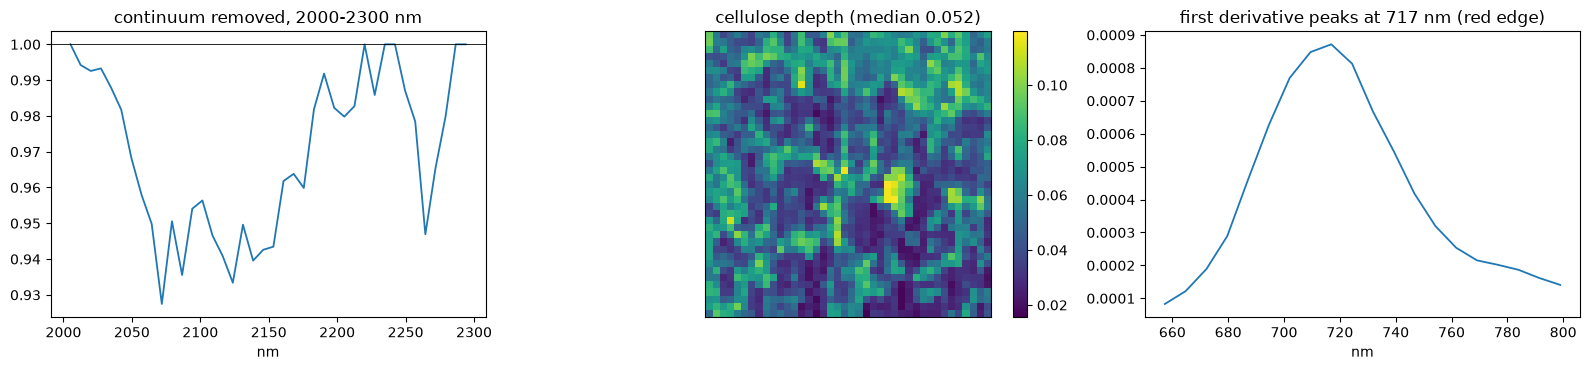

In [25]:
if RUN_POST:
    cr = hp.continuum_removal(patch, window=(2000, 2300))
    bd = hp.band_depth(patch, "cellulose")
    d1 = hp.spectral_derivative(patch, order=1, window=7, poly=2)
    wl = patch.wavelength.values
    inside = (wl >= 2000) & (wl <= 2300)
    fig, ax = plt.subplots(1, 3, figsize=(16, 3.8))
    ax[0].plot(wl[inside], cr[VAR].isel(y=20, x=20).values[inside], lw=1.3)
    ax[0].axhline(1, color="k", lw=0.6); ax[0].set_title("continuum removed, 2000-2300 nm")
    ax[0].set_xlabel("nm")
    im = ax[1].imshow(bd["depth"].values, cmap="viridis"); plt.colorbar(im, ax=ax[1], fraction=0.046)
    ax[1].set_title(f"cellulose depth (median {np.nanmedian(bd['depth'].values):.3f})")
    ax[1].set_xticks([]); ax[1].set_yticks([])
    prof = np.nanmedian(d1[VAR].values.reshape(-1, wl.size), axis=0)
    vis = (wl > 650) & (wl < 800)
    if vis.sum() > 3:
        ax[2].plot(wl[vis], prof[vis], lw=1.3)
        ax[2].set_title(f"first derivative peaks at {wl[vis][np.nanargmax(prof[vis])]:.0f} nm (red edge)")
    ax[2].set_xlabel("nm")
    plt.tight_layout(); plt.show()

### 6.3 Spectral indices

### `hp.spectral_index(ds, formula, var=None, tolerance=20.0, good_only=True, name=None)`

| Parameter | Default | What it does |
|---|---|---|
| `formula` | — | a registry name (`"NDVI"`), or an expression where `R<wavelength>` means the band nearest that wavelength in nm |
| `tolerance` | `20.0` | how far the nearest band may sit from the one asked for before the call fails |
| `good_only` | `True` | ignore bands flagged unusable |
| `name` | the index name | what to call the result |

Indices are addressed by **wavelength**, never band number, so one call runs unchanged on
a 224-band Classic line and a 426-band NEON line.

### `hp.describe_indices(ds=None, tolerance=20.0)`

The twelve built-in indices with formulas and citations, and which a given sensor can
compute. These instruments can compute all twelve.

In [26]:
if RUN_POST:
    print(hp.describe_indices(win_ds))

index   status     formula                                                    reference
------- ---------- ---------------------------------------------------------- ------------------------
NDVI    available  (R860 - R660) / (R860 + R660)                              Rouse et al. 1974
EVI     available  2.5 * (R860 - R660) / (R860 + 6*R660 - 7.5*R480 + 1)       Huete et al. 2002
NDWI    available  (R860 - R1240) / (R860 + R1240)                            Gao 1996
NDII    available  (R820 - R1650) / (R820 + R1650)                            Hunt and Rock 1989
PRI     available  (R531 - R570) / (R531 + R570)                              Gamon et al. 1992
NDNI    available  (log(1/R1510) - log(1/R1680)) / (log(1/R1510) + log(1/R1680)) Serrano et al. 2002
CAI     available  0.5 * (R2020 + R2220) - R2100                              Nagler et al. 2003
MCARI   available  ((R700 - R670) - 0.2 * (R700 - R550)) * (R700 / R670)      Daughtry et al. 2000
ARI1    available  1/R550 - 1/R700      

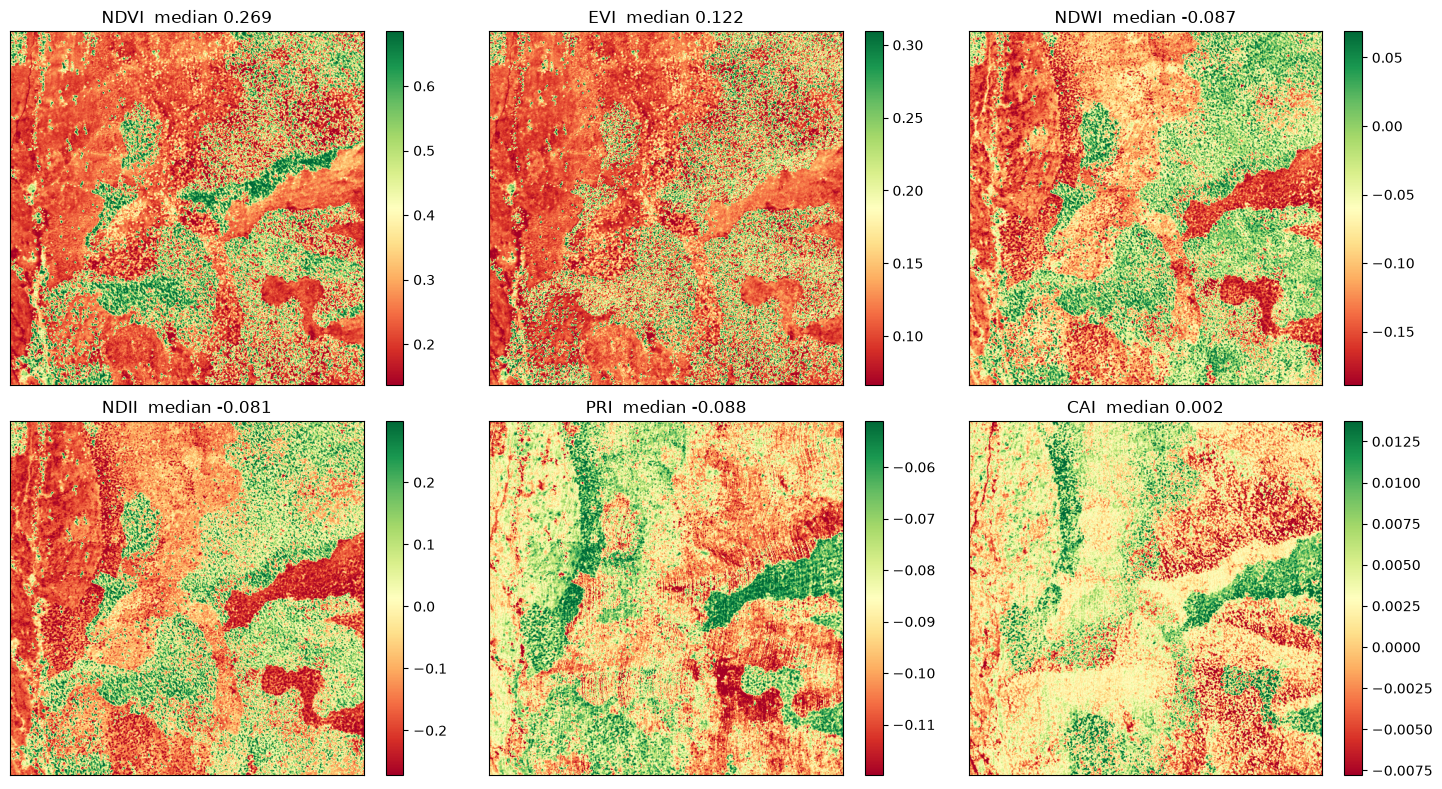

your own formula: (R800 - R670) / (R800 + R670)
bands it used   : R670=672.21 nm, R800=798.94 nm


In [27]:
if RUN_POST:
    names = ["NDVI", "EVI", "NDWI", "NDII", "PRI", "CAI"]
    fig, ax = plt.subplots(2, 3, figsize=(15, 8))
    for a, n in zip(ax.ravel(), names):
        v = hp.spectral_index(win_ds, n).values
        im = a.imshow(v, cmap="RdYlGn", vmin=np.nanpercentile(v, 2), vmax=np.nanpercentile(v, 98))
        a.set_title(f"{n}  median {np.nanmedian(v):.3f}"); a.set_xticks([]); a.set_yticks([])
        plt.colorbar(im, ax=a, fraction=0.046)
    plt.tight_layout(); plt.show()

    custom = hp.spectral_index(win_ds, "(R800 - R670) / (R800 + R670)", name="my_ndvi")
    print("your own formula:", custom.attrs["formula"])
    print("bands it used   :", custom.attrs["bands_used"])

### 6.4 Resampling to another instrument

### `hp.resample(data, ...)`

One matrix, so a whole scene moves in seconds. Name the target one of four ways:
`step`/`fwhm`/`wl_range` for a regular grid, `wavelengths`/`fwhm` for explicit bands,
`like=other_ds` to match another dataset, or `sensor="SENTINEL2A"` for a real instrument's
**measured** response.

| Parameter | Default | What it does |
|---|---|---|
| `method` | `None` | `None` uses a `sensor=` target's measured response, else `"gaussian"`. `"box"`, `"linear"`, `"cubic"`, `"nearest"` also exist |
| `min_coverage` | `0.5` | a target band with less of its response inside the source range comes back NaN instead of being renormalised |
| `allow_sharpening` | `False` | asking for bands narrower than the source is refused |
| `good_only` | `True` | exclude flagged bands from the convolution and the coverage |
| `return_coverage` | `False` | also return the per-band coverage fraction |

Simulating a broadband sensor from an airborne line is the usual reason to do this: it is
how you compare a flight against Landsat or Sentinel-2 over the same ground.

### `srf.available()` and `srf.fetch(sensor, cache=None, overwrite=False, verbose=True)`

| Call | What it does |
|---|---|
| `srf.available()` | the response functions the package knows, which are cached, and where each came from |
| `srf.fetch(sensor)` | downloads and caches one, returning its band names, centres, widths and the measured curve |

Sentinel-2 comes from ESA and Landsat 4 through 9 from the USGS. PlanetScope is listed as
*nominal*, meaning published band edges rather than a measured curve, and the entry says
so rather than letting you assume otherwise. `overwrite=True` re-downloads.

In [28]:
if RUN_POST:
    from hyperproc.spectral import srf
    print(srf.available())

sensor         kind      bands  cached  source
-------------- --------- -----  ------- ----------------------------------------
SENTINEL2A     measured     13  yes     ESA
SENTINEL2B     measured      -  no      ESA
LANDSAT4       measured      -  no      USGS
LANDSAT5       measured      -  no      USGS
LANDSAT7       measured      -  no      USGS
LANDSAT8       measured      9  yes     USGS
LANDSAT9       measured      -  no      USGS
PLANETSCOPE4   nominal       4  n/a     Planet (band edges only)
PLANETSCOPE8   nominal       8  n/a     Planet (band edges only)


  Sentinel-2A MSI [cached] SENTINEL2A.npz
Sentinel-2A MSI    dropped for low coverage: ['B10']
  Landsat 8 OLI [cached] LANDSAT8.npz


Landsat 8 OLI      dropped for low coverage: ['Cirrus']


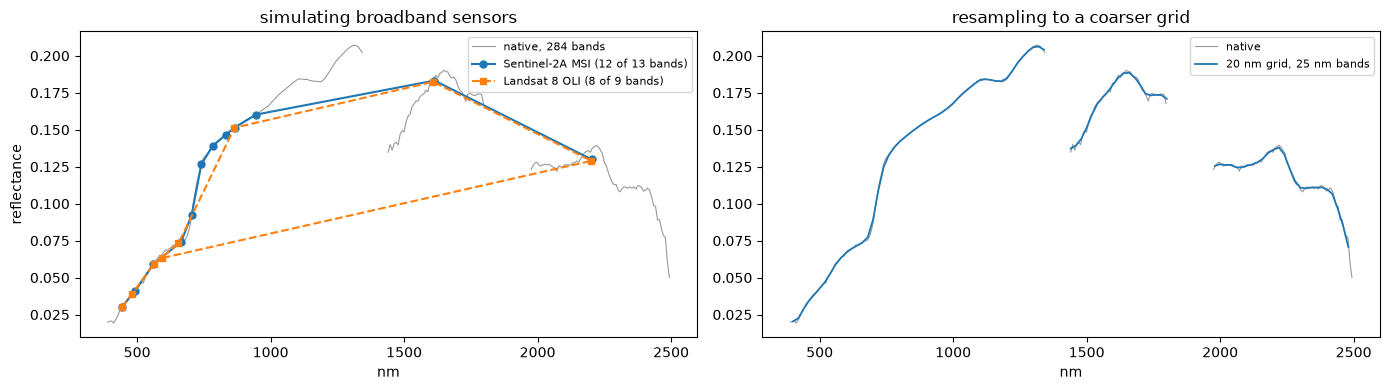


asking for 2 nm bands from a coarser instrument is refused:
   1052 target band(s) are narrower than the source: e.g. 390.0 nm asks for 2.00 nm from a source that measures 8.30 nm there. Resampling cannot raise sp ...


In [29]:
if RUN_POST:
    h = min(50, patch.sizes["y"] // 2, patch.sizes["x"] // 2)
    p2 = win_ds.isel(y=slice(cy - h, cy + h), x=slice(cx - h, cx + h)).compute()
    raw = np.asarray(p2[VAR].values[h // 2, h // 2], dtype="float64").copy()
    if "good_wavelength" in p2.coords:
        raw[~p2.good_wavelength.values.astype(bool)] = np.nan
    wl2 = p2.wavelength.values

    fig, ax = plt.subplots(1, 2, figsize=(14, 4))
    ax[0].plot(wl2, raw, color="0.6", lw=0.8, label=f"native, {wl2.size} bands")
    for sensor, style in (("SENTINEL2A", "o-"), ("LANDSAT8", "s--")):
        try:
            out = hp.resample(p2, sensor=sensor)
            got = srf.fetch(sensor, verbose=False)
            keep = np.isfinite(out[VAR].values[h // 2, h // 2])
            ax[0].plot(out.wavelength.values[keep], out[VAR].values[h // 2, h // 2][keep], style,
                       ms=5, label=f"{got['label']} ({keep.sum()} of {len(got['bands'])} bands)")
            print(f"{got['label']:18s} dropped for low coverage: "
                  f"{[b for b, kk in zip(got['bands'], keep) if not kk]}")
        except ValueError as exc:
            print(f"{sensor}: {str(exc)[:110]}")
    ax[0].legend(fontsize=8); ax[0].set_xlabel("nm"); ax[0].set_ylabel("reflectance")
    ax[0].set_title("simulating broadband sensors")

    grid = hp.resample(p2, step=20, fwhm=25)
    ax[1].plot(wl2, raw, color="0.6", lw=0.8, label="native")
    ax[1].plot(grid.wavelength.values, grid[VAR].values[h // 2, h // 2], lw=1.3,
               label="20 nm grid, 25 nm bands")
    ax[1].legend(fontsize=8); ax[1].set_xlabel("nm"); ax[1].set_title("resampling to a coarser grid")
    plt.tight_layout(); plt.show()

    try:
        hp.resample(p2, step=2, fwhm=2)
    except ValueError as exc:
        print("\nasking for 2 nm bands from a coarser instrument is refused:")
        print("  ", str(exc)[:150], "...")

## Step 7 — you already have `*_ac.tif`. Going on from there.

The retrieval ran days ago, the product is on disk, and you now want it topographically
and BRDF corrected without redoing an hour of ISOFIT.

Two things stand in the way, and both are worth understanding rather than working around.

**`hp.open` will not read a product back.** The readers identify granules by the
provider's naming, and a file this package wrote is not one. So a product is read with
`rasterio`, and the wavelengths come from the band descriptions in a GeoTIFF or from the
`wavelength` field in an ENVI header — one concrete reason to prefer ENVI for intermediates.

**The product carries no angles or terrain.** `process` writes the reflectance cube, the
retrieved layers and the quality flags, but not `cos_i`, `slope`, `sza`, `vza` or `raa` —
and both corrections need them. Either re-open the source flightline, which is on the same
grid, or write them at correction time with `hp.export_geometry` as step 2 did.

**One caveat, stated plainly.** The coefficients applied below were fitted on the
provider's reflectance, not on our own retrieval. The two agree closely (step 3 measured
it), and the coefficients describe the *surface and geometry* rather than the radiometry,
so transferring them is reasonable. It is not the same as refitting on your own product,
which would mean running the atmospheric correction on all 5 lines.

In [30]:
def load_product(path, geometry_from=None, var="reflectance", bands=None):
    '''Read a product this package wrote back into a dataset the corrections accept.

    path          a *_ac.tif or *_ac.img written by process() or hc.export()
    geometry_from an opened flightline on the same grid, to take the angles and
                  terrain from. None returns the cube alone, which is enough for
                  the spectral tools but not for a correction.
    bands         None reads every band; a list of 0-based indices reads only those.
    '''
    with rasterio.open(path) as src:
        envi = src.tags(ns="ENVI")
        if "wavelength" in envi:                       # ENVI states them as numbers
            wl = np.array([float(v) for v in envi["wavelength"].strip("{}").split(",")])
        else:                                          # GeoTIFF: parse the band labels
            wl = np.array([float(d.split()[0]) for d in src.descriptions])
        idx = list(range(src.count)) if bands is None else list(bands)
        cube = src.read([i + 1 for i in idx]).astype("float32")
        wl = wl[idx]
        tr, crs = src.transform, str(src.crs)
        ny, nx = src.height, src.width
    ds = xr.Dataset(
        {var: (("y", "x", "wavelength"), np.moveaxis(cube, 0, -1))},
        coords={"wavelength": wl,
                "x": tr.c + (np.arange(nx) + 0.5) * tr.a,
                "y": tr.f + (np.arange(ny) + 0.5) * tr.e},
        attrs={"crs": crs, "transform": tuple(tr.to_gdal()), "sensor": "AVIRIS3",
               "stem": Path(path).stem, "units": "1"})
    if geometry_from is not None:
        # `geometry_from` is already the matching window of the flightline - pass
        # window_of(ds0), not the whole line. Index, not coordinate: rotated grid.
        for layer in ("sza", "saa", "vza", "vaa", "raa", "slope", "aspect", "cos_i", "elev"):
            if layer in geometry_from:
                a = np.asarray(geometry_from[layer].values, dtype="float32")[:ny, :nx]
                if a.shape == (ny, nx):
                    ds[layer] = (("y", "x"), a)
    return ds


if RUN_AC:
    try:
        hp.open(ac["reflectance"])
    except ValueError as exc:
        print("hp.open on a product:", str(exc)[:96], "...")

hp.open on a product: Cannot tell what 'AV320231005t181518_L1B_ac_win3000-3500_400-900.tif' is. Pass sensor= and level ...


In [31]:
if RUN_AC and (RUN_TOPO or RUN_BRDF):
    saved = load_product(ac["reflectance"], geometry_from=window_of(ds0))
    print(f"loaded {Path(ac['reflectance']).name}")
    print(f"   {dict(saved.sizes)}  {saved.wavelength.values.min():.0f}-{saved.wavelength.values.max():.0f} nm")
    print(f"   attached: {[v for v in ('sza','vza','raa','cos_i','slope') if v in saved]}")

    corrected = hc.apply(saved, topo=topos[0] if RUN_TOPO else None,
                         brdf=bc_after if RUN_BRDF else None,
                         notes={"coefficients": "fitted on the provider reflectance group"},
                         force_topo=True)
    p = hp.to_raster(corrected, OUT / "07_from_saved_ac" /
                     f"{Path(ac['reflectance']).stem}_topo_brdf{EXT}",
                     format=EXPORT_FORMAT,
                     **({"overviews": True} if EXPORT_FORMAT == "GTiff" else {}))
    print(f"\nwrote {p.name} ({p.stat().st_size/1e6:.0f} MB)")

    k = int(np.argmin(np.abs(saved.wavelength.values - DIAG_NM)))
    before = saved.reflectance.isel(wavelength=k).values
    after = corrected.reflectance.isel(wavelength=k).values
    ok = np.isfinite(before) & np.isfinite(after) & (before > 0.01)
    print(f"median change at {DIAG_NM:.0f} nm on our own product: "
          f"{np.median((after[ok]-before[ok])/before[ok])*100:+.2f} %")

loaded AV320231005t181518_L1B_ac_win3000-3500_400-900.tif
   {'y': 500, 'x': 500, 'wavelength': 284}  390-2494 nm
   attached: ['sza', 'vza', 'raa', 'cos_i', 'slope']


/home/fujiang/miniconda3/envs/hsi/lib/python3.12/site-packages/rioxarray/rioxarray.py:431: UserWarning: Transform that is non-rectilinear or with rotation found. Unable to recalculate.
  warnings.warn(



wrote AV320231005t181518_L1B_ac_win3000-3500_400-900_topo_brdf.tif (217 MB)


median change at 865 nm on our own product: -3.35 %


## What this notebook exercised

In [32]:
exercised = {
 "reading":     ["hp.open", "hp.sniff", "hp.describe", "hp.main_var"],
 "export":      ["hp.to_geotiff", "hp.to_envi", "hp.to_raster", "hp.to_geotiff_2d",
                 "hp.bands_to_csv", "hp.export_geometry", "hc.export"],
 "atmospheric": ["hp.atmos.check", "hp.atmos.process"],
 "correction":  ["hc.sample_image", "hc.fit_topo",
                 "hc.angular_diversity", "hc.fit_brdf", "hc.apply", "hc.view_dependence",
                 "hc.find_overlapping_pair", "hc.seam_check", "hc.load"],
 "quality":     ["hp.quality_flags", "hp.quality_table", "hp.quality_apply", "hp.quality_decode"],
 "spectral":    ["hp.smooth_spectra", "hp.spline_gapfill", "hp.continuum_removal",
                 "hp.spectral_derivative", "hp.resample", "srf.available", "srf.fetch"],
 "features":    ["hp.spectral_index", "hp.describe_indices", "hp.band_depth"],
}
print(f"{sum(len(v) for v in exercised.values())} entry points across {len(exercised)} areas:\n")
for area, fns in exercised.items():
    print(f"  {area:14s} {', '.join(fns)}")
print(f"\nproducts written under {OUT}:")
for p in sorted(OUT.rglob("*")):
    if p.is_file() and p.suffix in (".tif", ".img", ".hdr", ".csv", ".json") and "isofit" not in str(p):
        print(f"   {p.relative_to(OUT)}  ({p.stat().st_size/1e6:.1f} MB)")

36 entry points across 7 areas:

  reading        hp.open, hp.sniff, hp.describe, hp.main_var
  export         hp.to_geotiff, hp.to_envi, hp.to_raster, hp.to_geotiff_2d, hp.bands_to_csv, hp.export_geometry, hc.export
  atmospheric    hp.atmos.check, hp.atmos.process
  correction     hc.sample_image, hc.fit_topo, hc.angular_diversity, hc.fit_brdf, hc.apply, hc.view_dependence, hc.find_overlapping_pair, hc.seam_check, hc.load
  quality        hp.quality_flags, hp.quality_table, hp.quality_apply, hp.quality_decode
  spectral       hp.smooth_spectra, hp.spline_gapfill, hp.continuum_removal, hp.spectral_derivative, hp.resample, srf.available, srf.fetch
  features       hp.spectral_index, hp.describe_indices, hp.band_depth

products written under /data/fujiang/Hyperspectral_data_processing/tests/output/AVIRIS3:


   01_read/demo.hdr  (0.0 MB)
   01_read/demo.img  (4.1 MB)
   01_read/demo.tif  (3.1 MB)
   01_read/demo_bands.csv  (0.0 MB)
   01_read/geometry/AV320231005t181518_L2A_cos_i.tif  (0.0 MB)
   01_read/geometry/AV320231005t181518_L2A_raa.tif  (0.0 MB)
   01_read/geometry/AV320231005t181518_L2A_slope.tif  (0.0 MB)
   01_read/geometry/AV320231005t181518_L2A_sza.tif  (0.0 MB)
   01_read/geometry/AV320231005t181518_L2A_vza.tif  (0.0 MB)
   02_ac/AV320231005t181518_L1B_ac_win3000-3500_400-900.tif  (216.7 MB)
   02_ac/AV320231005t181518_L1B_ac_win3000-3500_400-900_aot550.tif  (0.9 MB)
   02_ac/AV320231005t181518_L1B_ac_win3000-3500_400-900_bands.csv  (0.0 MB)
   02_ac/AV320231005t181518_L1B_ac_win3000-3500_400-900_h2o.tif  (0.8 MB)
   02_ac/AV320231005t181518_L1B_ac_win3000-3500_400-900_provenance.json  (0.0 MB)
   02_ac/AV320231005t181518_L1B_ac_win3000-3500_400-900_quality.tif  (0.0 MB)
   03_coefficients/AV320231005t181518_L2A_topo_coeffs.json  (0.1 MB)
   03_coefficients/AV320231005t182159

## Notes

AVIRIS-3 delivers each flightline as one orthorectified scene with both levels side by side, which makes it the simplest of the airborne set to follow.

**What the verdicts mean, and why they are the honest part.** `fit_topo` and `fit_brdf`
both report whether the data supports the fit, and on airborne data the answer is often
`inconclusive` — a line whose terrain is uniform cannot show a terrain effect, and a group
flown on one heading cannot separate the kernels. This notebook forces the corrections
anyway so you can see their size, which is a tutorial's job. **In production, let the
verdict decide.**

**What this notebook does not show.** The corrected products here cover one
500 x 500 window. The coefficients were fitted
from samples of the full lines, so they are the same ones a full-flightline run would use —
only the export is small. To write whole lines, drop `window=` from `hc.export` and budget
the disk: a single AVIRIS-3 flightline runs to tens of gigabytes per stage.

The satellite notebooks in this folder cover the other half of the package: the MODIS
c-factor BRDF route, which is what you use when a sensor cannot see enough angles to fit
its own model.